# Metódy objavovania znalostí z časových radov

Tento notebook je metodicky usporiadaný podľa **CRISP-DM**:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation


## 1. Business Understanding

**Cieľ:** Predikovať vývoj cien nehnuteľností na základe historických transakcií (časový rad), porovnať vybrané modely a vyhodnotiť ich presnosť.

**Výstupy:** predikcie (log cena aj USD), porovnanie modelov (SARIMAX, Prophet, LSTM + baseline), metriky a štatistické testy.


## 2. Data Understanding

V tejto časti sa dataset načíta, spojí a preskúma: štruktúra, premenné, distribúcie, chýbajúce hodnoty, duplicity, časová kontinuita, outliery a základné trendy.


In [ ]:


required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "statsmodels",
    "scipy",
    "scikit-learn",
    "pmdarima",
    "prophet",
    "tensorflow==2.15.0",
    "kagglehub"
]

for package in required_packages:
    !pip install {package}


Načítanie datasetu

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andykrause/kingcountysales")

print("Path to dataset files:", path)

c:\Users\dmagdolen\Desktop\test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\dmagdolen\.cache\kagglehub\datasets\andykrause\kingcountysales\versions\9


In [3]:
import os
print("Path:", path)
print(os.listdir(path))

Path: C:\Users\dmagdolen\.cache\kagglehub\datasets\andykrause\kingcountysales\versions\9
['kingcountysales.csv', 'kingcountysales_2000_2023.csv', 'kingco_sales.csv']


In [4]:
import pandas as pd

kingco = pd.read_csv(os.path.join(path, "kingco_sales.csv"))
sales_2000_2023 = pd.read_csv(os.path.join(path, "kingcountysales_2000_2023.csv"))
sales_all = pd.read_csv(os.path.join(path, "kingcountysales.csv"))


In [5]:
kingco.head(2)

,sale_id,pinx,sale_date,sale_price,sale_nbr,sale_warning,join_status,join_year,latitude,longitude,...,view_olympics,view_cascades,view_territorial,view_skyline,view_sound,view_lakewash,view_lakesamm,view_otherwater,view_other,submarket
0,1999..144,..2734100475,1999-01-05,150000,1.0,,demo,1999,47.544359,-122.320786,...,0,0,0,0,0,0,0,0,0,E
1,1999..258,..1535200725,1999-01-05,235000,1.0,,demo,1999,47.421247,-122.438139,...,0,0,2,0,0,0,0,0,0,H


In [6]:
sales_2000_2023.head(2)

,Unnamed: 0,sale_id,pinx,sale_date,sale_price,sale_nbr,sale_warning,join_status,join_year,latitude,...,view_olympics,view_cascades,view_territorial,view_skyline,view_sound,view_lakewash,view_lakesamm,view_otherwater,view_other,submarket
0,1,1999..144,..2734100475,1999-01-05,150000,1.0,,demo,1999,47.544359,...,0,0,0,0,0,0,0,0,0,E
1,2,1999..258,..1535200725,1999-01-05,235000,1.0,,demo,1999,47.421247,...,0,0,2,0,0,0,0,0,0,H


In [7]:
sales_all.head(2)

,Unnamed: 0,sale_id,pinx,sale_date,sale_price,sale_nbr,sale_warning,join_status,join_year,latitude,...,view_olympics,view_cascades,view_territorial,view_skyline,view_sound,view_lakewash,view_lakesamm,view_otherwater,view_other,submarket
0,1,1999..144,..2734100475,1999-01-05,150000,1,,demo,1999,47.544359,...,0,0,0,0,0,0,0,0,0,E
1,2,1999..258,..1535200725,1999-01-05,235000,1,,demo,1999,47.421247,...,0,0,2,0,0,0,0,0,0,H


In [8]:
kingco.shape

(605614, 48)

In [9]:
sales_2000_2023.shape

(575319, 49)

In [10]:
sales_all.shape

(560219, 49)

Spojenie datasetov


In [11]:
import pandas as pd


kingco_ids = set(kingco["sale_id"])
sales_2000_2023_ids = set(sales_2000_2023["sale_id"])
sales_all_ids = set(sales_all["sale_id"])

common_all = kingco_ids & sales_2000_2023_ids & sales_all_ids
print("Riadky spoločné pre všetky datasety:", len(common_all))

common_kingco_2000 = kingco_ids & sales_2000_2023_ids
print("Riadky spoločné pre kingco a sales_2000_2023:", len(common_kingco_2000))

common_2000_2023_all = sales_2000_2023_ids & sales_all_ids
print("Riadky spoločné pre sales_2000_2023 a sales_all:", len(common_2000_2023_all))

common_sales_all_kingco = sales_all_ids & kingco_ids
print("Riadky spoločné pre sales_all a kingco:", len(common_sales_all_kingco))

unique_kingco = kingco_ids - (sales_2000_2023_ids | sales_all_ids)
print("Riadky iba v kingco:", len(unique_kingco))

unique_2000_2023 = sales_2000_2023_ids - (kingco_ids | sales_all_ids)
print("Riadky iba v sales_2000_2023:", len(unique_2000_2023))

unique_sales_all = sales_all_ids - (kingco_ids | sales_2000_2023_ids)
print("Riadky iba v sales_all:", len(unique_sales_all))




Riadky spoločné pre všetky datasety: 514107
Riadky spoločné pre kingco a sales_2000_2023: 542872
Riadky spoločné pre sales_2000_2023 a sales_all: 537518
Riadky spoločné pre sales_all a kingco: 518436
Riadky iba v kingco: 58413
Riadky iba v sales_2000_2023: 9036
Riadky iba v sales_all: 18372


In [12]:
cols_kingco = set(kingco.columns)
cols_2000_2023 = set(sales_2000_2023.columns)
cols_all = set(sales_all.columns)

common_cols = cols_kingco & cols_2000_2023 & cols_all
print("Stĺpce spoločné pre všetky datasety:", len(common_cols))

unique_kingco = cols_kingco - (cols_2000_2023 | cols_all)
unique_2000_2023 = cols_2000_2023 - (cols_kingco | cols_all)
unique_all = cols_all - (cols_kingco | cols_2000_2023)

print("Stĺpce len v kingco:", unique_kingco)
print("Stĺpce len v sales_2000_2023:", unique_2000_2023)
print("Stĺpce len v sales_all:", unique_all)


Stĺpce spoločné pre všetky datasety: 48
Stĺpce len v kingco: set()
Stĺpce len v sales_2000_2023: set()
Stĺpce len v sales_all: set()


In [13]:
import pandas as pd

combined = pd.concat(
    [kingco, sales_2000_2023, sales_all],
    ignore_index=True
)

combined['sale_date'] = pd.to_datetime(combined['sale_date'])

combined = combined.sort_values('sale_date')

kingco = combined.drop_duplicates(
    subset='sale_id',
    keep='last'
).reset_index(drop=True)


print(f"Finálny kingco: {len(kingco)} riadkov")
print(f"Unikátne sale_id: {kingco['sale_id'].nunique()}")
assert kingco['sale_id'].is_unique



Finálny kingco: 656433 riadkov
Unikátne sale_id: 656433


In [14]:
kingco.shape

(656433, 49)

Opis premenných

In [15]:
kingco.columns


Index(['sale_id', 'pinx', 'sale_date', 'sale_price', 'sale_nbr',
       'sale_warning', 'join_status', 'join_year', 'latitude', 'longitude',
       'area', 'city', 'zoning', 'subdivision', 'present_use', 'land_val',
       'imp_val', 'year_built', 'year_reno', 'sqft_lot', 'sqft', 'sqft_1',
       'sqft_fbsmt', 'grade', 'fbsmt_grade', 'condition', 'stories', 'beds',
       'bath_full', 'bath_3qtr', 'bath_half', 'garb_sqft', 'gara_sqft', 'wfnt',
       'golf', 'greenbelt', 'noise_traffic', 'view_rainier', 'view_olympics',
       'view_cascades', 'view_territorial', 'view_skyline', 'view_sound',
       'view_lakewash', 'view_lakesamm', 'view_otherwater', 'view_other',
       'submarket', 'Unnamed: 0'],
      dtype='object')

| Stĺpec               | Význam                                                                               |
| -------------------- | ------------------------------------------------------------------------------------ |
| **Unnamed: 0**       | Automaticky generovaný index pri načítaní CSV.                                       |
| **sale_id**          | Jedinečné ID predaja nehnuteľnosti.                                                  |
| **pinx**             | Parcel Identification Number – identifikátor parcely.                                |
| **sale_date**        | Dátum predaja nehnuteľnosti.                                                         |
| **sale_price**       | Cena predaja (v USD).                                                                |
| **sale_nbr**         | Číslo predaja alebo počet predajov tejto nehnuteľnosti (možno opakujúce sa predaje). |
| **sale_warning**     | Možné upozornenie pri predaji (napr. podozrivé transakcie).                          |
| **join_status**      | Status spojenia dát, napr. "demo" znamená demografické dáta priradené.               |
| **join_year**        | Rok, ku ktorému bolo spojenie dát vykonané.                                          |
| **latitude**         | Zemepisná šírka (GPS).                                                               |
| **longitude**        | Zemepisná dĺžka (GPS).                                                               |
| **area**             | Veľkosť pozemku, často v štvorcových stopách alebo iných jednotkách.                 |
| **city**             | Mesto, kde sa nehnuteľnosť nachádza.                                                 |
| **zoning**           | Zónovanie nehnuteľnosti           |
| **subdivision**      | Názov sídliska alebo časti mesta.                                                    |
| **present_use**      | Súčasné využitie nehnuteľnosti
| **land_val**         | Hodnota pozemku (v USD).                                                             |
| **imp_val**          | Hodnota stavby/úpravy (improvement value) – hodnota domu stavby na pozemku.          |
| **year_built**       | Rok výstavby nehnuteľnosti.                                                          |
| **year_reno**        | Rok renovácie (ak bola).                                                             |
| **sqft_lot**         | Veľkosť pozemku v štvorcových stopách.                                               |
| **sqft**             | Celková obytná plocha (celkovo alebo podľa konkrétneho záznamu).                     |
| **sqft_1**           | Pravdepodobne obytná plocha prvého poschodia.                                        |
| **sqft_fbsmt**       | Plocha suterénu (finished basement) v štvorcových stopách.                           |
| **grade**            | Hodnotenie kvality stavby (čím vyššie číslo, tým lepšia kvalita).                    |
| **fbsmt_grade**      | Hodnotenie kvality suterénu.                                                         |
| **condition**        | Stav nehnuteľnosti (1 = zlý, 5 = výborný).                                     |
| **stories**          | Počet poschodí.                                                                      |
| **beds**             | Počet spální.                                                                        |
| **bath_full**        | Počet plných kúpeľní.                                                                |
| **bath_3qtr**        | Počet kúpeľní s tromi štvrtinami vybavenia.                                          |
| **bath_half**        | Počet polovičných kúpeľní.                                                           |
| **garb_sqft**        | Pravdepodobne obytná plocha garáže     |
| **gara_sqft**        | Veľkosť garáže v štvorcových stopách.                                                |
| **wfnt**             | Waterfront – či je nehnuteľnosť pri vode (0/1).                                      |
| **golf**             | Blízkosť k golfovému ihrisku (0/1).                                                  |
| **greenbelt**        | Blízkosť k chránenej zelene, parku alebo lese (0/1).                                 |
| **noise_traffic**    | Úroveň hluku alebo dopravného ruchu (0 až 3)                           |
| **view_rainier**     | Výhľad na Mount Rainier (0/1).                                                       |
| **view_olympics**    | Výhľad na pohorie Olympic (0/1).                                                     |
| **view_cascades**    | Výhľad na pohorie Cascade (0/1).                                                     |
| **view_territorial** | Výhľad na územné oblasti (0/1).                                                      |
| **view_skyline**     | Výhľad na mestskú panorámu (0/1).                                                    |
| **view_sound**       | Výhľad na Puget Sound alebo iné vodné plochy (0/1).                                  |
| **view_lakewash**    | Výhľad na Lake Washington (0/1).                                                     |
| **view_lakesamm**    | Výhľad na Lake Sammamish (0/1).                                                      |
| **view_otherwater**  | Výhľad na iné vodné plochy (0/1).                                                    |
| **view_other**       | Iné typy výhľadov (0/1).                                                             |
| **submarket**        | Podtrh alebo lokalita pre realitný trh v King County.                                |


## 3. Data Preparation

V tejto časti sa vykoná príprava dát pre modelovanie (čistenie, typy dát, agregácie na mesačnú úroveň, transformácie ako `log_price`, výber premenných / feature engineering).


In [16]:
kingco = kingco.drop(columns=['Unnamed: 0'], errors='ignore')

In [17]:
kingco.shape

(656433, 48)

Distribúcia dát

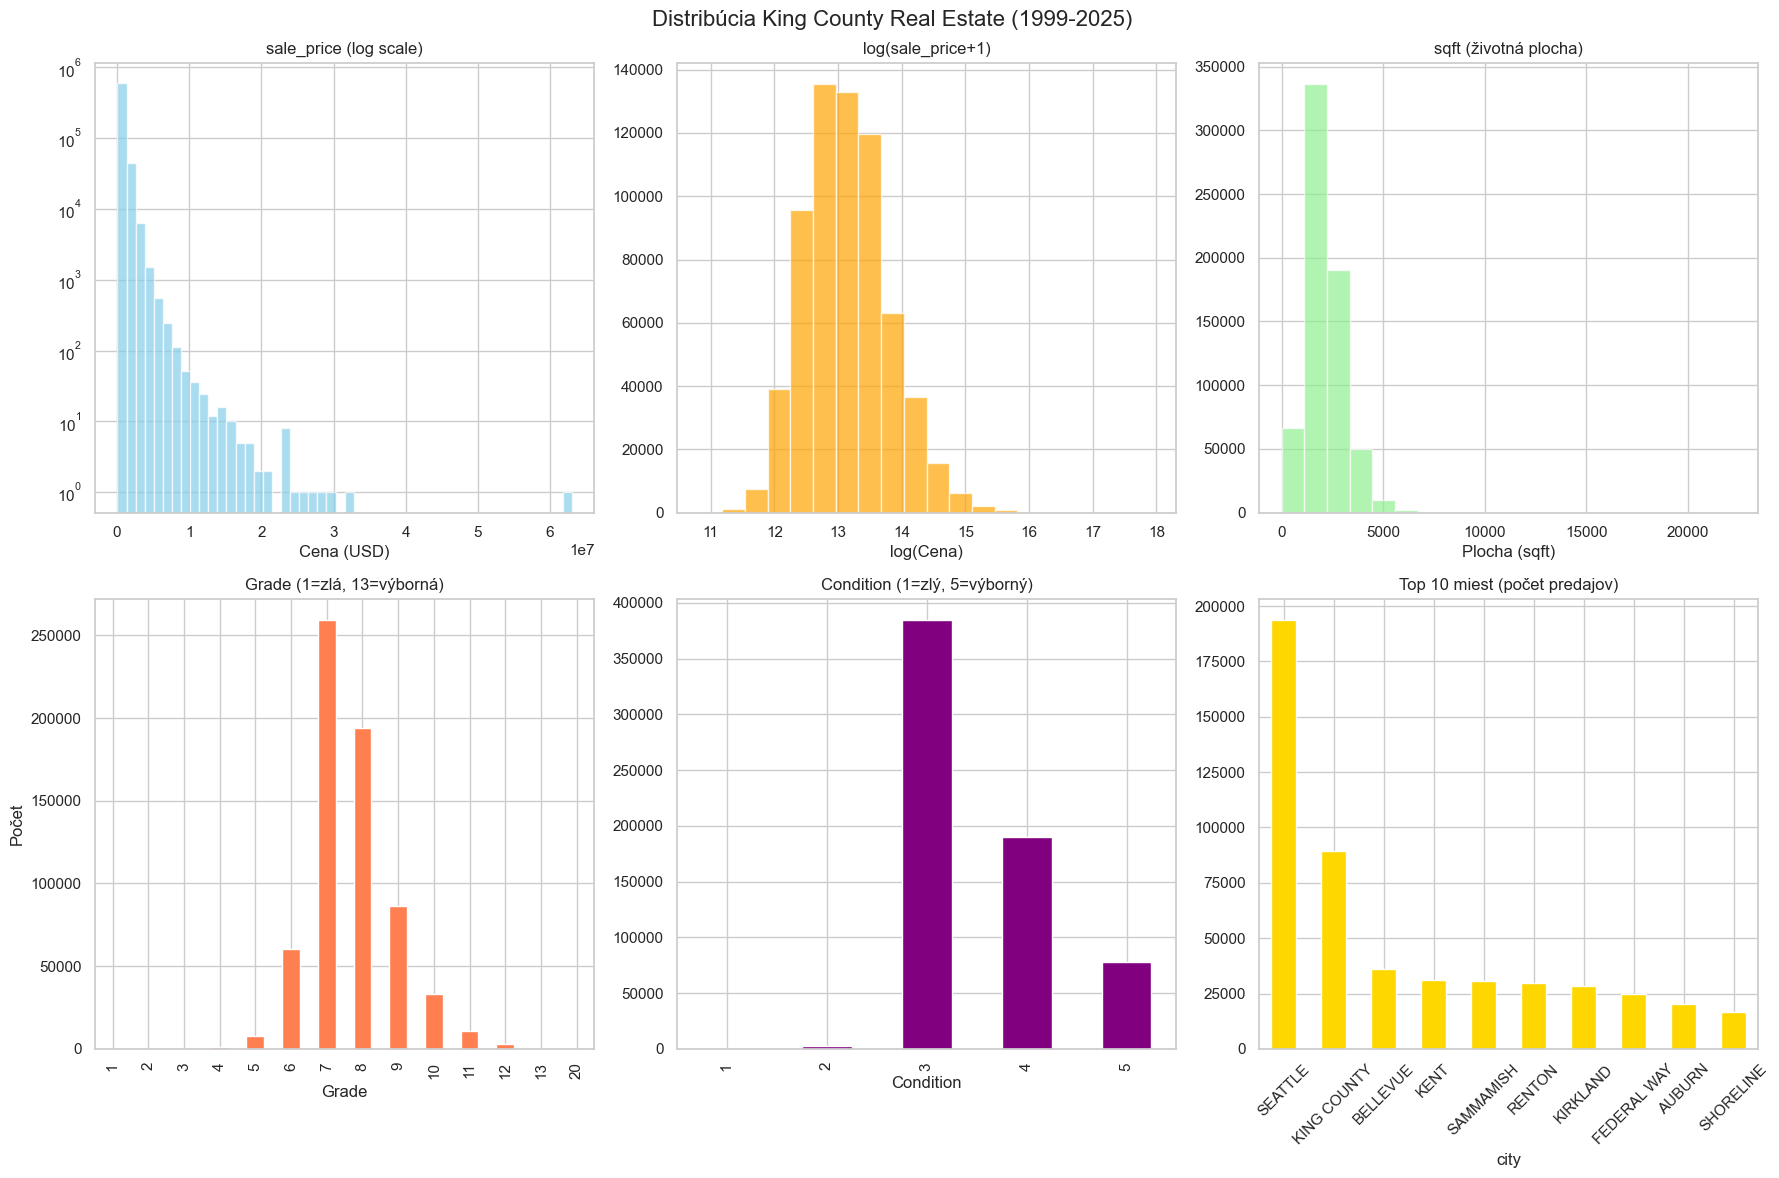

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)

# Štýl len pre túto jednu figúru (neovplyvní ďalšie grafy)
with sns.axes_style("whitegrid"), sns.plotting_context("notebook"):

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Distribúcia King County Real Estate (1999-2025)', fontsize=16)

    # 1. Cena (raw vs log)
    axes[0,0].hist(kingco['sale_price'].dropna(), bins=50, alpha=0.7, color='skyblue', log=True)
    axes[0,0].set_title('sale_price (log scale)')
    axes[0,0].set_xlabel('Cena (USD)')
    # (bez ylabel – ako na "peknej" verzii)

    axes[0,1].hist(np.log1p(kingco['sale_price'].dropna()), bins=20, alpha=0.7, color='orange')
    axes[0,1].set_title('log(sale_price+1)')
    axes[0,1].set_xlabel('log(Cena)')

    # 2. Plocha (sqft)
    axes[0,2].hist(kingco['sqft'].dropna(), bins=20, alpha=0.7, color='lightgreen')
    axes[0,2].set_title('sqft (životná plocha)')
    axes[0,2].set_xlabel('Plocha (sqft)')

    # 3. Grade (kvalita stavby)
    kingco['grade'].dropna().value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='coral')
    axes[1,0].set_title('Grade (1=zlá, 13=výborná)')
    axes[1,0].set_xlabel('Grade')
    axes[1,0].set_ylabel('Počet')

    # 4. Condition (stav)
    kingco['condition'].dropna().value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='purple')
    axes[1,1].set_title('Condition (1=zlý, 5=výborný)')
    axes[1,1].set_xlabel('Condition')

    # 5. Mesta (top 10)
    top_cities = kingco['city'].dropna().value_counts().head(10)
    top_cities.plot(kind='bar', ax=axes[1,2], color='gold')
    axes[1,2].set_title('Top 10 miest (počet predajov)')
    axes[1,2].set_xlabel('city')
    axes[1,2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('kingco_distribucia.png', dpi=300, bbox_inches='tight')
    plt.show()


In [19]:

numeric_cols = kingco.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerické stĺpce: {len(numeric_cols)}")

# Kompletné kategórie
categories = {
    '1 CENA': ['sale_price'],
    '2 VEĽKOSŤ': ['sqft', 'sqft_1', 'sqft_lot', 'sqft_fbsmt', 'beds', 'bath_full', 'bath_3qtr', 'bath_half'],
    '3 KVALITA': ['grade', 'condition', 'fbsmt_grade'],
    '4 GARÁŽ': ['garb_sqft', 'gara_sqft'],
    '5 VÝHĽAD_BINÁRNE': [col for col in numeric_cols if col.startswith('view_') or col in ['wfnt', 'golf', 'greenbelt']],
    '6 LOKALITA_BINÁRNE': ['noise_traffic'],
    '7 HODNOTY_POZEMOK': ['land_val', 'imp_val'],
    '8 VEK': ['year_built', 'year_reno'],
    '9 POZEMOK': ['area'],
    '10 INÉ': ['sale_nbr', 'join_year', 'present_use', 'stories']
}

# VÝPOČET + TABUĽKA
summary = []
for cat, cols in categories.items():
    valid_cols = [c for c in cols if c in numeric_cols]
    if valid_cols:
        corrs = kingco[valid_cols].corrwith(kingco['sale_price']).dropna()
        corr_mean = corrs.abs().mean()
        top_corr = corrs.abs().max()
        summary.append([cat, len(valid_cols), f"{corr_mean:.3f}", f"{top_corr:.3f}", valid_cols[:3]])

df_summary = pd.DataFrame(summary, columns=['Kategória', 'Stĺpce', 'Priemerná |r|', 'Max |r|', 'Príklady'])
print(df_summary.to_markdown())


Numerické stĺpce: 39
|    | Kategória          |   Stĺpce |   Priemerná |r| |   Max |r| | Príklady                                 |
|---:|:-------------------|---------:|----------------:|----------:|:-----------------------------------------|
|  0 | 1 CENA             |        1 |           1     |     1     | ['sale_price']                           |
|  1 | 2 VEĽKOSŤ          |        8 |           0.212 |     0.428 | ['sqft', 'sqft_1', 'sqft_lot']           |
|  2 | 3 KVALITA          |        3 |           0.191 |     0.412 | ['grade', 'condition', 'fbsmt_grade']    |
|  3 | 4 GARÁŽ            |        2 |           0.068 |     0.12  | ['garb_sqft', 'gara_sqft']               |
|  4 | 5 VÝHĽAD_BINÁRNE   |       13 |           0.119 |     0.306 | ['wfnt', 'golf', 'greenbelt']            |
|  5 | 6 LOKALITA_BINÁRNE |        1 |           0.007 |     0.007 | ['noise_traffic']                        |
|  6 | 7 HODNOTY_POZEMOK  |        2 |           0.45  |     0.476 | ['land_val', '

In [20]:
import pandas as pd
import numpy as np

kingco = kingco.copy()

for c in ['beds', 'sqft', 'sqft_lot', 'sale_price']:
    kingco[c] = pd.to_numeric(kingco[c], errors='coerce')

kingco = kingco.dropna(subset=['beds', 'sqft', 'sale_price'])

kingco['beds'] = kingco['beds'].round().astype(int)

kingco['beds_cat'] = pd.cut(
    kingco['beds'],
    bins=[-1, 0, 1, 2, 3, np.inf],
    labels=['0', '1', '2', '3', '4+']
)

kingco['sqft_lot'] = kingco['sqft_lot'].fillna(0)

kingco['lot_cat'] = pd.cut(
    kingco['sqft_lot'],
    bins=[-1, 0, 1000, 5000, 10000, 20000, np.inf],
    labels=['bez pozemku','malý','stredný','väčší','veľký','veľmi veľký']
)

# tabuľka podľa beds
table_beds = kingco.groupby('beds_cat', observed=False).agg(
    pocet=('sale_price','size'),
    median_cena=('sale_price','median')
).reset_index()

table_beds['podiel_pct'] = (table_beds['pocet'] / len(kingco) * 100).round(1)
table_beds['median_cena'] = table_beds['median_cena'].round(0)

print("PREHĽAD NEHNUTEĽNOSTÍ PODĽA POČTU SPÁLNÍ")
print(table_beds.to_markdown(index=False))

# pivot count
pivot_count = pd.pivot_table(
    kingco, index='beds_cat', columns='lot_cat',
    values='sale_price', aggfunc='size',
    fill_value=0, observed=False
)

print("ŠTRUKTÚRA NEHNUTEĽNOSTÍ – POČTY")
print(pivot_count.to_markdown())

# pivot median price
pivot_price = pd.pivot_table(
    kingco, index='beds_cat', columns='lot_cat',
    values='sale_price', aggfunc='median',
    observed=False
).round(0)

print("MEDIÁN CENY PODĽA SPÁLNÍ A POZEMKU")
print(pivot_price.to_markdown())

n_3plus = (kingco['beds'] >= 3).sum()
share_3plus = n_3plus / len(kingco) * 100
print(f"Nehnuteľnosti s ≥3 spálňami: {n_3plus:,} ({share_3plus:.1f} %)")


PREHĽAD NEHNUTEĽNOSTÍ PODĽA POČTU SPÁLNÍ
| beds_cat   |   pocet |   median_cena |   podiel_pct |
|:-----------|--------:|--------------:|-------------:|
| 0          |     328 |        441000 |          0   |
| 1          |    6181 |        375500 |          0.9 |
| 2          |   76311 |        400600 |         11.6 |
| 3          |  282874 |        429000 |         43.1 |
| 4+         |  290739 |        584950 |         44.3 |
ŠTRUKTÚRA NEHNUTEĽNOSTÍ – POČTY
| beds_cat   |   bez pozemku |   malý |   stredný |   väčší |   veľký |   veľmi veľký |
|:-----------|--------------:|-------:|----------:|--------:|--------:|--------------:|
| 0          |             0 |     22 |        88 |     111 |      61 |            46 |
| 1          |             0 |    204 |      2384 |    2020 |     765 |           808 |
| 2          |             0 |   5080 |     30781 |   29603 |    6601 |          4246 |
| 3          |             1 |   4113 |     73487 |  133840 |   46622 |         24811 |
| 4+   

In [21]:
print(kingco["sale_date"].min(), "-", kingco["sale_date"].max())
print(kingco.shape)

1999-01-01 00:00:00 - 2025-12-31 00:00:00
(656433, 50)


Kontrola chýbajúcich hodnôt

In [22]:
print("\nPočet chýbajúcich hodnôt v každom stĺpci")
kingco.isnull().sum().sort_values(ascending=False).head(5)


Počet chýbajúcich hodnôt v každom stĺpci


sale_nbr       97475
subdivision    59172
submarket       2261
pinx               0
sale_price         0
dtype: int64

Tieto stĺpce nie sú využívané v ďalšej analýze ani pri tvorbe predikčných modelov. Z tohto dôvodu s nimi nie sú vykonané žiadne imputácie ani odstraňovanie záznamov.

Prediktory ceny

ČISTÝ TOP 10:
land_val            0.476
sqft                0.428
imp_val             0.425
grade               0.412
sqft_1              0.312
view_lakewash       0.306
view_territorial    0.257
latitude            0.227
sale_nbr            0.219
beds                0.193
dtype: float64


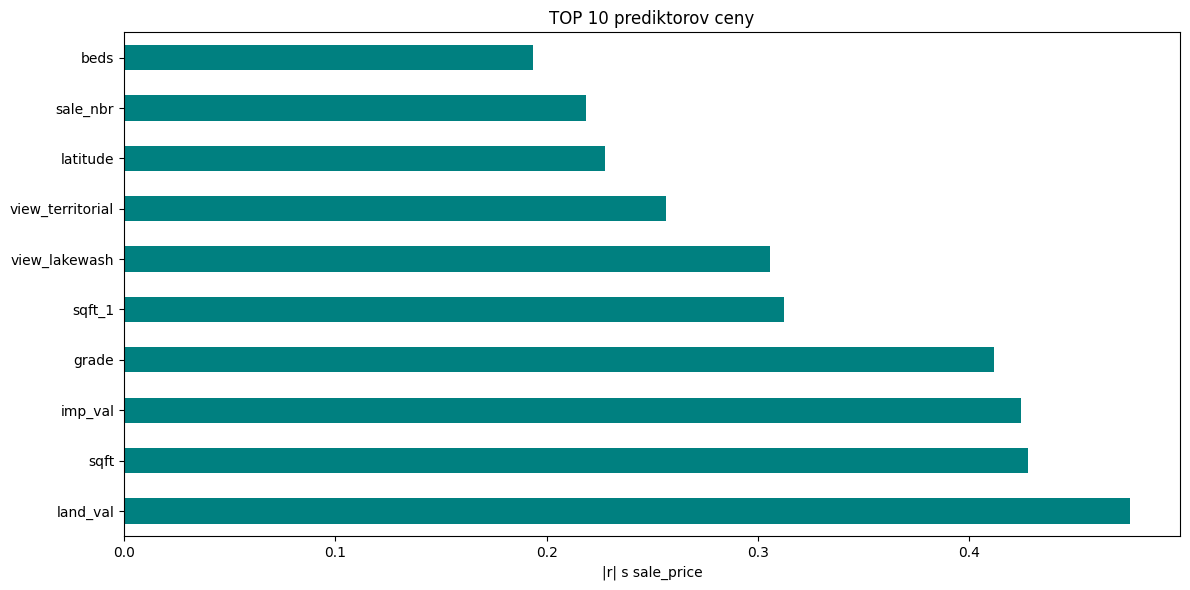

In [23]:
exclude = ['sale_price', 'log_price']
numeric_cols = kingco.select_dtypes(include=['number']).columns

corrs = (kingco[numeric_cols.drop(exclude, errors='ignore')]
         .corrwith(kingco['sale_price'])
         .abs().sort_values(ascending=False))

print("ČISTÝ TOP 10:")
print(corrs.head(10).round(3))

corrs.head(10).plot(kind='barh', figsize=(12,6), color='teal')
plt.title('TOP 10 prediktorov ceny')
plt.xlabel('|r| s sale_price')
plt.tight_layout()
plt.savefig('top10_final.png', dpi=300)
plt.show()


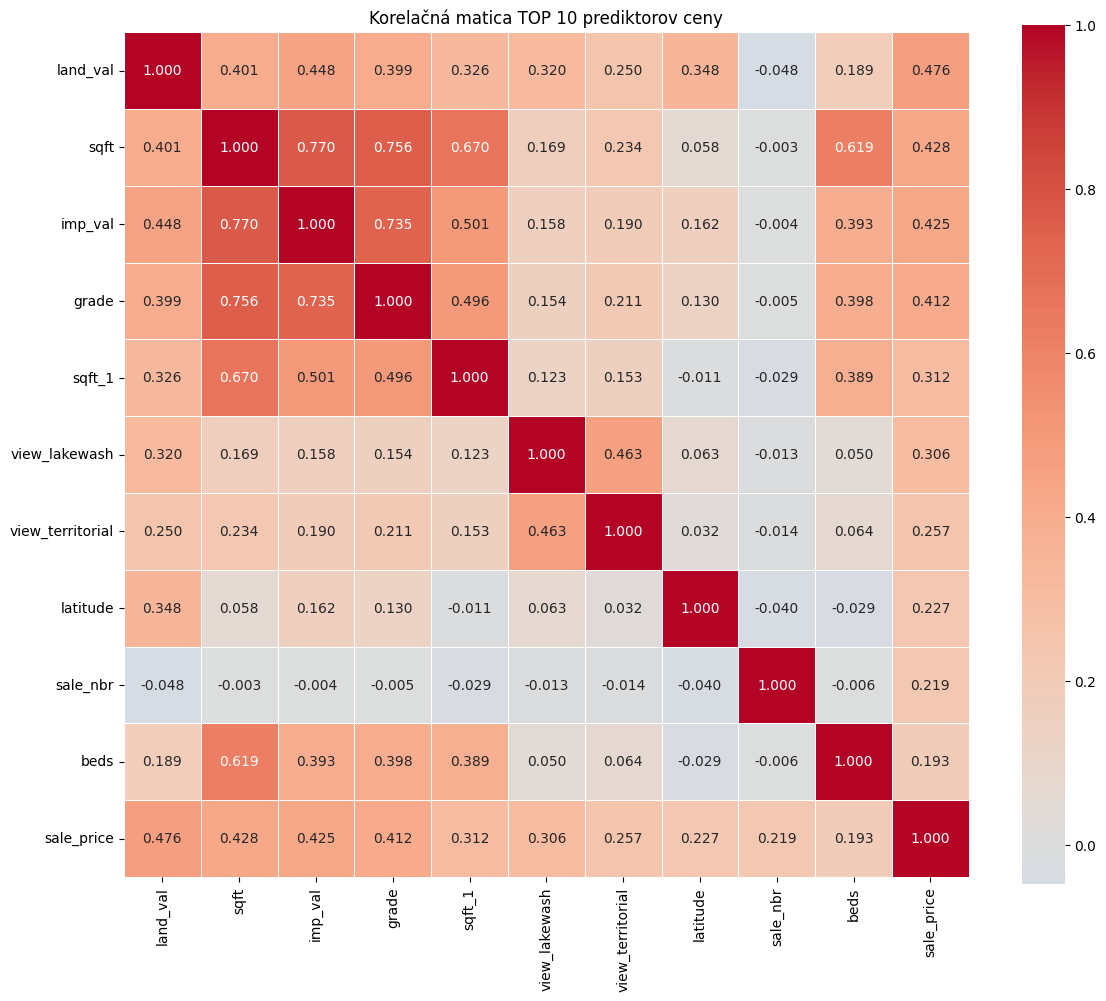

In [24]:
# TOP 10 z tvojho výstupu
top10_cols = ['land_val', 'sqft', 'imp_val', 'grade', 'sqft_1',
              'view_lakewash', 'view_territorial', 'latitude',
              'sale_nbr', 'beds']

corr = kingco[top10_cols + ['sale_price']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True,
            fmt='.3f', linewidths=0.5)
plt.title('Korelačná matica TOP 10 prediktorov ceny')
plt.tight_layout()
plt.savefig('kingco_korelace_top10.png', dpi=300)
plt.show()


Kontrola mesačnej kontinuity

In [25]:
kingco['sale_date'] = pd.to_datetime(kingco['sale_date'])
monthly_periods = kingco['sale_date'].dt.to_period('M').unique()
print(f"Unikátne mesiace: {len(monthly_periods)}")
print(f"Očakávané: {((monthly_periods.max() - monthly_periods.min()).n + 1)}")
print("Chýbajúce:", len(monthly_periods) == (monthly_periods.max() - monthly_periods.min()).n + 1)



Unikátne mesiace: 324
Očakávané: 324
Chýbajúce: True


zachovaná mesačná kontinuita

In [26]:
print("\nPočet unikátnych nehnuteľností:", kingco["pinx"].nunique())
print("Počet predajov:", len(kingco))


Počet unikátnych nehnuteľností: 345695
Počet predajov: 656433


In [27]:
kingco[kingco["condition"].isin([1,2,3,4,5])].groupby("condition")["sale_price"].describe()


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
1,713.0,706886.100982,924243.165437,57500.0,280000.0,469950.0,798000.0,10150000.0
2,2935.0,710927.218399,924753.850956,55000.0,260000.0,450000.0,750000.0,11300000.0
3,384416.0,640783.120130,572804.318645,50293.0,322500.0,494950.0,760000.0,30000000.0
4,190405.0,620065.543746,599085.425871,51580.0,297670.0,455000.0,735000.0,32000000.0
5,77964.0,705082.692704,658363.695688,50500.0,342237.5,540000.0,850000.0,63000000.0


Condition - Stav nehnuteľnosti 1 = zlý, 5 = výborný

In [28]:
kingco["noise_traffic"].value_counts().sort_index()


noise_traffic
0    568722
1     51064
2     31995
3      4652
Name: count, dtype: int64

0 = veľmi tichá / pokojná lokalita (najlepšie)
3 = veľmi hlučná / rušná lokalita (najhoršie)

In [29]:
duplicates = kingco.duplicated(subset="sale_id").sum()
print(f"\nPočet duplicitných predajov (sale_id): {duplicates}")


Počet duplicitných predajov (sale_id): 0


In [30]:
duplicates = kingco.duplicated(subset="sale_id").sum()
print(f"\nPočet duplicitných predajov (sale_id): {duplicates}")


Počet duplicitných predajov (sale_id): 0


Identifikacia outliers:

In [31]:
Q1 = kingco["sale_price"].quantile(0.25)
Q3 = kingco["sale_price"].quantile(0.75)
IQR = Q3 - Q1

# Definovať outliery
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = kingco[(kingco["sale_price"] < lower_bound) | (kingco["sale_price"] > upper_bound)]
print(f"Počet outlierov: {len(outliers)}")

outliers[["sale_price", "condition", "sqft", "city"]].head()


Počet outlierov: 42822


,sale_price,condition,sqft,city
148,1625000,5,4740,MEDINA
195,1490000,3,4190,MERCER ISLAND
455,4160000,4,2380,SEATTLE
689,2950000,3,6190,SEATTLE
870,2500000,3,6250,KING COUNTY


In [32]:
# Outliery podľa city (top 10 miest)
outliers_city = outliers.groupby("city")["sale_price"].count().sort_values(ascending=False).head(10)
print("\nTop 10 miest s najviac outliermi:")
print(outliers_city)



Top 10 miest s najviac outliermi:
city
SEATTLE          11893
BELLEVUE          6805
KING COUNTY       4768
KIRKLAND          4029
SAMMAMISH         3619
MERCER ISLAND     3139
REDMOND           1714
ISSAQUAH          1062
MEDINA             883
CLYDE HILL         863
Name: sale_price, dtype: int64


Počet outlierov: 42973 - treba logaritmovať sale_price - pomôže zjemniť extrémy

In [33]:
kingco['sale_price'].describe()


count    6.564330e+05
mean     6.427960e+05
std      5.942320e+05
min      5.029300e+04
25%      3.169000e+05
50%      4.875000e+05
75%      7.650000e+05
max      6.300000e+07
Name: sale_price, dtype: float64

In [34]:
import numpy as np
kingco["log_price"] = np.log1p(kingco["sale_price"])


In [35]:
kingco['log_price'].describe()


count    656433.000000
mean         13.135994
std           0.654768
min          10.825641
25%          12.666345
50%          13.097048
75%          13.547632
max          17.958645
Name: log_price, dtype: float64

In [36]:
kingco.head(1)

,sale_id,pinx,sale_date,sale_price,sale_nbr,sale_warning,join_status,join_year,latitude,longitude,area,city,zoning,subdivision,present_use,land_val,imp_val,year_built,year_reno,sqft_lot,sqft,sqft_1,sqft_fbsmt,grade,fbsmt_grade,condition,stories,beds,bath_full,bath_3qtr,bath_half,garb_sqft,gara_sqft,wfnt,golf,greenbelt,noise_traffic,view_rainier,view_olympics,view_cascades,view_territorial,view_skyline,view_sound,view_lakewash,view_lakesamm,view_otherwater,view_other,submarket,beds_cat,lot_cat,log_price
0,1999..221,..2740600105,1999-01-01,128000,1.0,,nochg,2023,47.555408,-122.317781,79,SEATTLE,NR3,GERMANIA ADD DIV NO. 01,2,291000,219000,1917,0,5000,800,800,0,6,0,4,1.0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,E,2,stredný,11.759793


In [37]:
import numpy as np

# kontrola z log_price pre prvý riadok
test = np.expm1(kingco["log_price"].iloc[0])
print(f"{test:,.0f}")



128,000


In [38]:
Q1 = kingco["log_price"].quantile(0.25)
Q3 = kingco["log_price"].quantile(0.75)
IQR = Q3 - Q1

# Definovať outliery
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = kingco[(kingco["log_price"] < lower_bound) | (kingco["log_price"] > upper_bound)]
print(f"Počet outlierov: {len(outliers)}")

# Zobraziť niekoľko príkladov
outliers[["log_price", "condition", "sqft", "city"]].head()


Počet outlierov: 6918


,log_price,condition,sqft,city
255,11.289794,3,1180,SEATTLE
385,11.326608,5,550,TUKWILA
455,15.241026,4,2380,SEATTLE
610,11.302217,4,730,SEATTLE
689,14.897316,3,6190,SEATTLE


In [39]:
pd.reset_option('display.float_format')


Year to Year trend

In [40]:
import pandas as pd
import numpy as np

# ročný priemer a medián cien
annual_prices = (
    kingco
    .assign(year=kingco['sale_date'].dt.year)
    .groupby('year')['sale_price']
    .agg(['mean', 'median'])
    .reset_index()
)

# medziročný rast (%)
annual_prices['mean_growth_%'] = annual_prices['mean'].pct_change() * 100
annual_prices['median_growth_%'] = annual_prices['median'].pct_change() * 100


annual = annual_prices.dropna().reset_index(drop=True)

annual.head()


,year,mean,median,mean_growth_%,median_growth_%
0,2000,307895.049608,250000.0,8.780692,8.695652
1,2001,312126.216618,260000.0,1.374224,4.000000
2,2002,330480.187791,276000.0,5.880304,6.153846
3,2003,348110.418006,295000.0,5.334731,6.884058
4,2004,384002.622164,325000.0,10.310580,10.169492


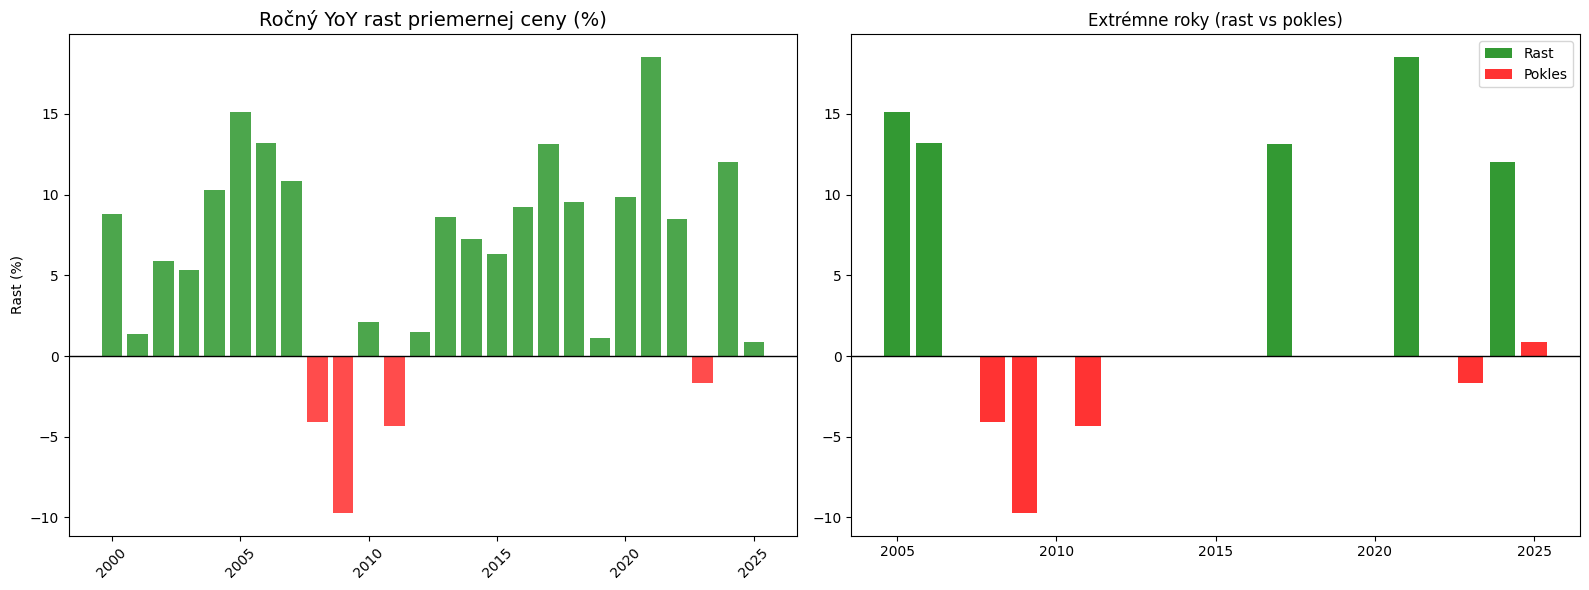

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graf 1: Celý rad rastu
ax1.bar(annual['year'], annual['mean_growth_%'], color=['red' if x < 0 else 'green' for x in annual['mean_growth_%']], alpha=0.7)
ax1.axhline(0, color='black', lw=1)
ax1.set_title('Ročný YoY rast priemernej ceny (%)', fontsize=14)
ax1.set_ylabel('Rast (%)')
ax1.tick_params(axis='x', rotation=45)

# Graf 2: Highlight top rast/pokles
top_rast = annual.nlargest(5, 'mean_growth_%')[['year', 'mean_growth_%']]
bottom_pokles = annual.nsmallest(5, 'mean_growth_%')[['year', 'mean_growth_%']]
ax2.bar(top_rast['year'], top_rast['mean_growth_%'], color='green', alpha=0.8, label='Rast')
ax2.bar(bottom_pokles['year'], bottom_pokles['mean_growth_%'], color='red', alpha=0.8, label='Pokles')
ax2.axhline(0, color='black', lw=1)
ax2.set_title('Extrémne roky (rast vs pokles)')
ax2.legend()

plt.tight_layout()
plt.show()


In [42]:
# Top 5 rastov a poklesov - ready na diplomku
top_rast = annual.nlargest(3, 'mean_growth_%')[['mean_growth_%', 'median_growth_%']].round(2)
top_rast.index = annual.nlargest(3, 'mean_growth_%')['year'].astype(int).astype(str)
top_rast.columns = ['Rast priemer (%)', 'Rast medián (%)']

bottom_pokles = annual.nsmallest(3, 'mean_growth_%')[['mean_growth_%', 'median_growth_%']].round(2)
bottom_pokles.index = annual.nsmallest(3, 'mean_growth_%')['year'].astype(int).astype(str)
bottom_pokles.columns = ['Pokles priemer (%)', 'Pokles medián (%)']

print("Najväčšie ročné rasty cien")
print(top_rast.to_markdown())

print("\nNajväčšie ročné poklesy cien")
print(bottom_pokles.to_markdown())


Najväčšie ročné rasty cien
|   year |   Rast priemer (%) |   Rast medián (%) |
|-------:|-------------------:|------------------:|
|   2021 |              18.52 |             13.7  |
|   2005 |              15.11 |             13.94 |
|   2006 |              13.22 |             13.96 |

Najväčšie ročné poklesy cien
|   year |   Pokles priemer (%) |   Pokles medián (%) |
|-------:|---------------------:|--------------------:|
|   2009 |                -9.71 |               -8.68 |
|   2011 |                -4.33 |               -3.1  |
|   2008 |                -4.07 |               -4.77 |


In [43]:
# Priemerný YoY rast podľa MESIACA (cez všetky roky)
kingco['sale_date'] = pd.to_datetime(kingco['sale_date'])
kingco['month'] = kingco['sale_date'].dt.month
kingco['year'] = kingco['sale_date'].dt.year


monthly_pivot = kingco.groupby(['month', 'year'])['sale_price'].mean().unstack(level=1)


monthly_growth = monthly_pivot.pct_change(axis=1) * 100

# Priemer rastu za každý mesiac
avg_monthly_growth = monthly_growth.mean(axis=1).round(2).sort_values(ascending=False)

print("Priemerný YoY rast cien podľa mesiaca (cez všetky roky)")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Máj', 'Jún',
               'Júl', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec']

avg_monthly_growth.index = month_names
print(avg_monthly_growth.to_markdown())


Priemerný YoY rast cien podľa mesiaca (cez všetky roky)
|     |    0 |
|:----|-----:|
| Jan | 6.79 |
| Feb | 6.46 |
| Mar | 6.44 |
| Apr | 6.23 |
| Máj | 6.21 |
| Jún | 6.18 |
| Júl | 6.16 |
| Aug | 6.14 |
| Sep | 6.12 |
| Okt | 6.12 |
| Nov | 5.78 |
| Dec | 5.69 |


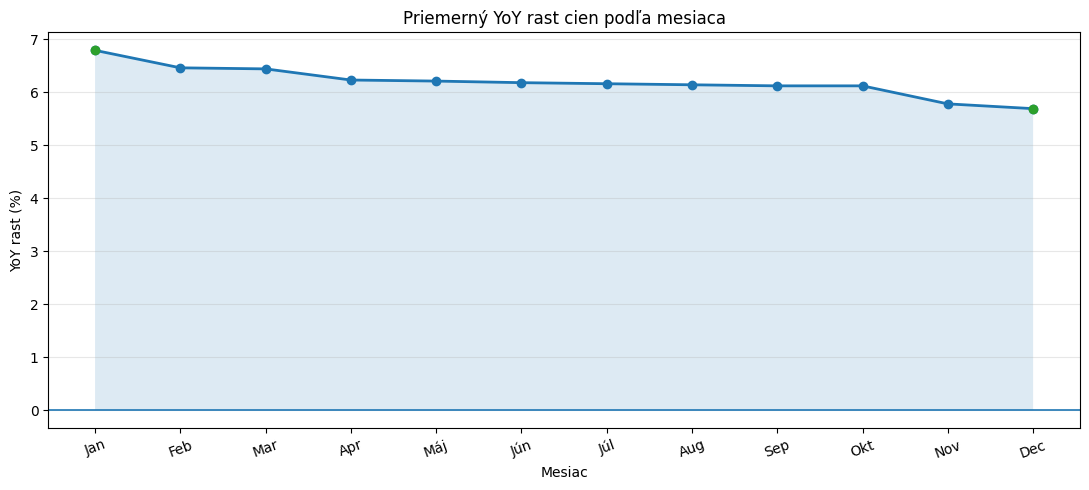

In [44]:
plt.figure(figsize=(11, 5))

plt.plot(
    avg_monthly_growth.index,
    avg_monthly_growth.values,
    marker='o',
    linewidth=2
)

plt.fill_between(
    avg_monthly_growth.index,
    avg_monthly_growth.values,
    0,
    where=(avg_monthly_growth.values >= 0),
    alpha=0.15
)

plt.fill_between(
    avg_monthly_growth.index,
    avg_monthly_growth.values,
    0,
    where=(avg_monthly_growth.values < 0),
    alpha=0.15
)

plt.axhline(0, linewidth=1.2)

# zvýraznenie max / min
max_m = avg_monthly_growth.idxmax()
min_m = avg_monthly_growth.idxmin()

plt.scatter(
    [max_m, min_m],
    [avg_monthly_growth[max_m], avg_monthly_growth[min_m]],
    zorder=3
)

plt.title('Priemerný YoY rast cien podľa mesiaca')
plt.xlabel('Mesiac')
plt.ylabel('YoY rast (%)')

plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Mesačný časový rad: 324 pozorovaní
               price_mean  sales_count  log_price_mean
sale_date                                             
1999-01-01  274173.791217         1389       12.521521
1999-02-01  267507.166033         1578       12.496905
1999-03-01  271116.241663         2189       12.510307
1999-04-01  285486.373444         2169       12.561953
1999-05-01  278602.722799         2215       12.537546


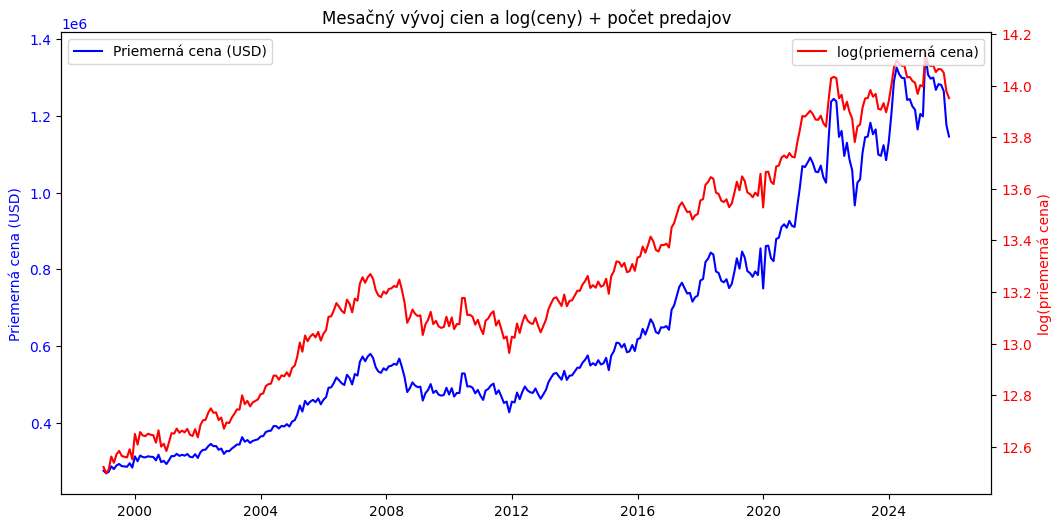

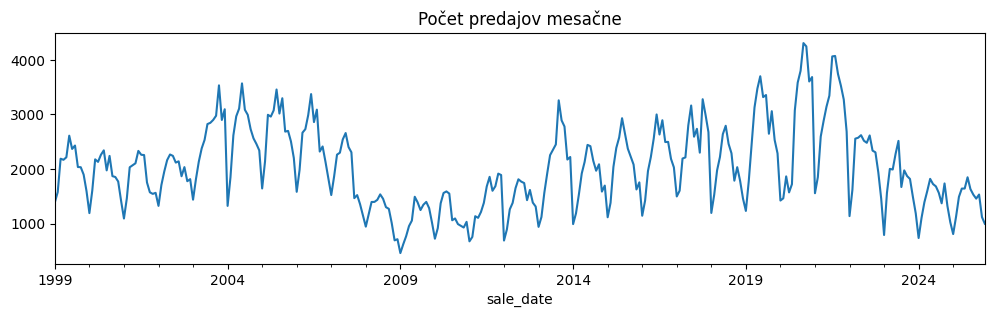

In [45]:
import matplotlib.pyplot as plt
import numpy as np

monthly_sales = (kingco.groupby(kingco['sale_date'].dt.to_period('M'))['sale_price']
                 .agg(['mean', 'count'])
                 .reset_index())
monthly_sales['sale_date'] = monthly_sales['sale_date'].dt.to_timestamp()
monthly_sales.set_index('sale_date', inplace=True)
monthly_sales.rename(columns={'mean': 'price_mean', 'count': 'sales_count'}, inplace=True)

monthly_sales['log_price_mean'] = np.log1p(monthly_sales['price_mean'])

print(f"Mesačný časový rad: {len(monthly_sales)} pozorovaní")
print(monthly_sales.head())

# Graf pôvodných cien a log(ceny)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly_sales.index, monthly_sales['price_mean'], color='blue', label='Priemerná cena (USD)')
ax1.set_ylabel('Priemerná cena (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(monthly_sales.index, monthly_sales['log_price_mean'], color='red', label='log(priemerná cena)')
ax2.set_ylabel('log(priemerná cena)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Mesačný vývoj cien a log(ceny) + počet predajov')
plt.show()

# Sekundárny graf počtu predajov
monthly_sales['sales_count'].plot(figsize=(12, 3), title='Počet predajov mesačne')
plt.show()


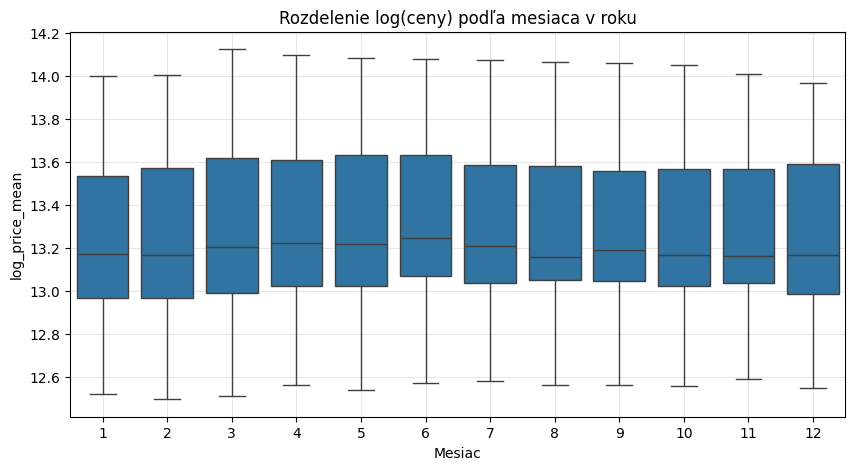

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

df = monthly_sales.copy()
df['year'] = df.index.year
df['month'] = df.index.month

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='month', y='log_price_mean')
plt.title('Rozdelenie log(ceny) podľa mesiaca v roku')
plt.xlabel('Mesiac')
plt.ylabel('log_price_mean')
plt.grid(True, alpha=0.3)
plt.show()


Dekompozícia časového radu + stacionarita

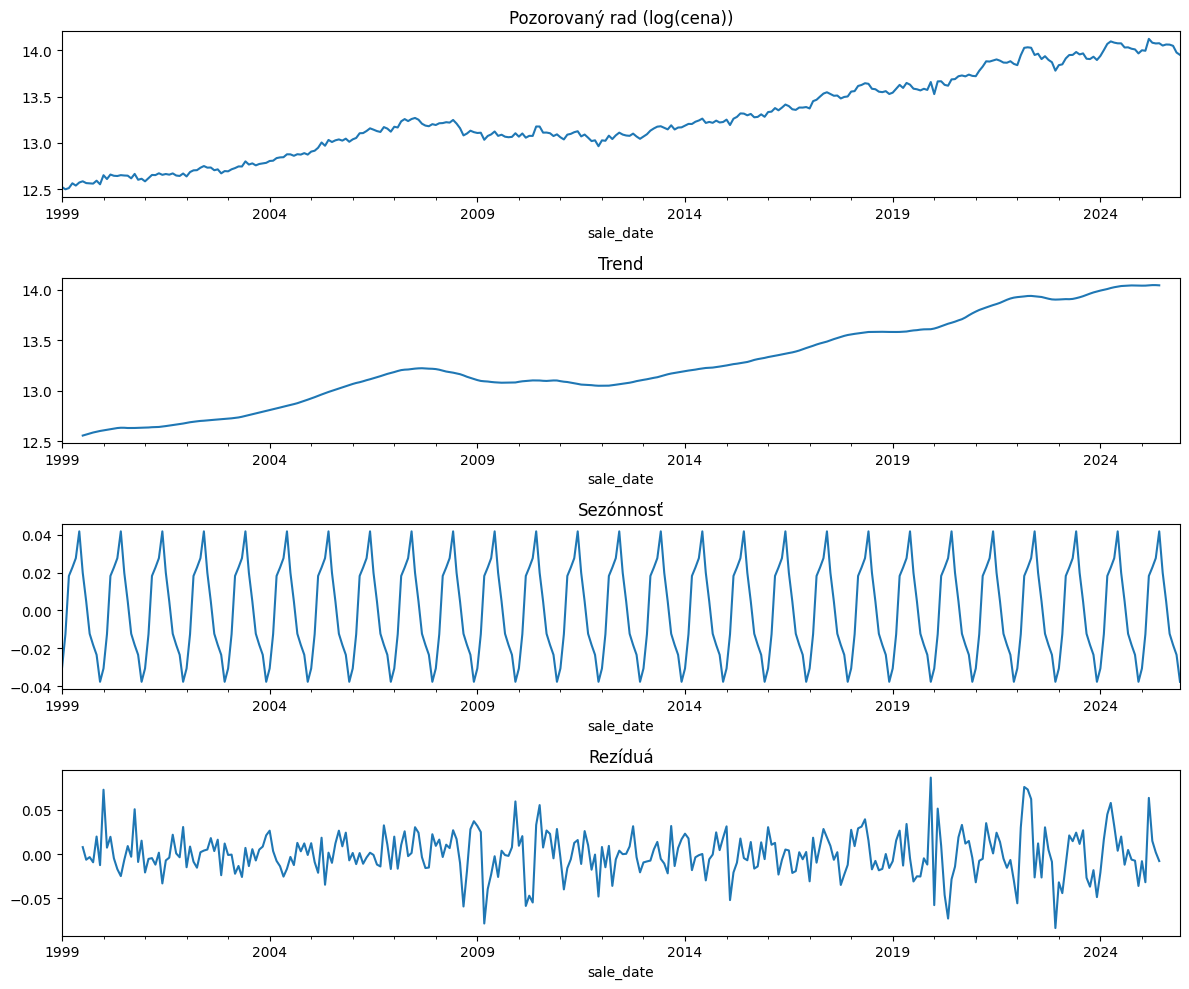

In [47]:
# dekompozícia
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(monthly_sales['log_price_mean'], model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomp.observed.plot(ax=axes[0], title='Pozorovaný rad (log(cena))')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Sezónnosť')
decomp.resid.plot(ax=axes[3], title='Rezíduá')
plt.tight_layout()
plt.show()


Rezíduá = "vysvetlenie chyby" – zvyšok po odčítaní trendu + sezónnosti

log_price(t) = Trend(t) + Sezóna(t) + ε(t)
     ε(t) = log_price(t) - [Trend(t) + Sezóna(t)]

In [48]:
# stacionarita
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales['log_price_mean'])
print('ADF statistic:', result[0])
print('p-value:', result[1])
print('Stacionárny' if result[1] < 0.05 else 'Nestacionárny')


ADF statistic: -0.5846783614372043
p-value: 0.8744066415530611
Nestacionárny


In [49]:
# 1. Prvá diferencovaná rada
monthly_sales['log_price_diff'] = monthly_sales['log_price_mean'].diff()

ts_diff = monthly_sales['log_price_diff'].dropna()

from statsmodels.tsa.stattools import adfuller
result_diff = adfuller(ts_diff)
print('ADF diff statistic:', result_diff[0])
print('p-value:', result_diff[1])
print('Stacionárny' if result_diff[1] < 0.05 else 'Nestacionárny')


ADF diff statistic: -2.9853943583947102
p-value: 0.03628107972627499
Stacionárny


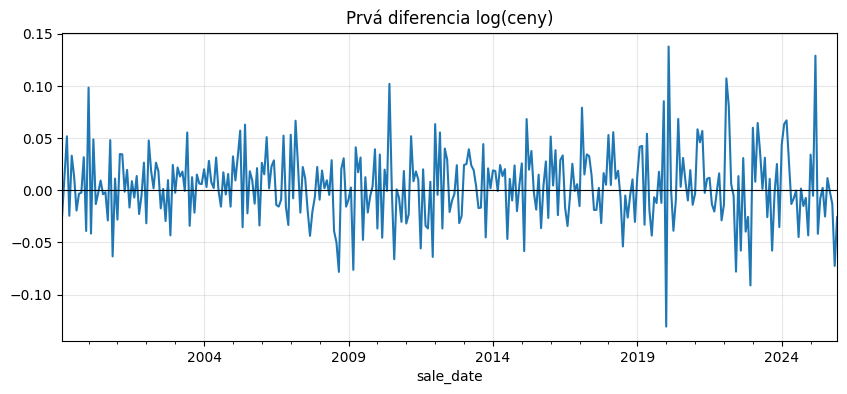

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) plný mesačný rad
ts = monthly_sales['log_price_mean']
# 2) prvá diferencia (stacionárny rad)
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,4))
ts_diff.plot(title='Prvá diferencia log(ceny)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.show()

celý mesačný časový rad priemernej log ceny.
..
ts.diff() – pre každý mesiac spočíta rozdiel - teda zmenu log(ceny) oproti predchádzajúcemu mesiacu.

dropna() len odstráni prvú hodnotu (tam nie je predchádzajúci mesiac).

Graf  zobrazuje mesačné zmeny log(ceny)

mesiace s neobvykle veľkým nárastom alebo poklesom priemernej ceny – kandidáti na vysvetlenie (covid 2019, finančná kríza 2009).

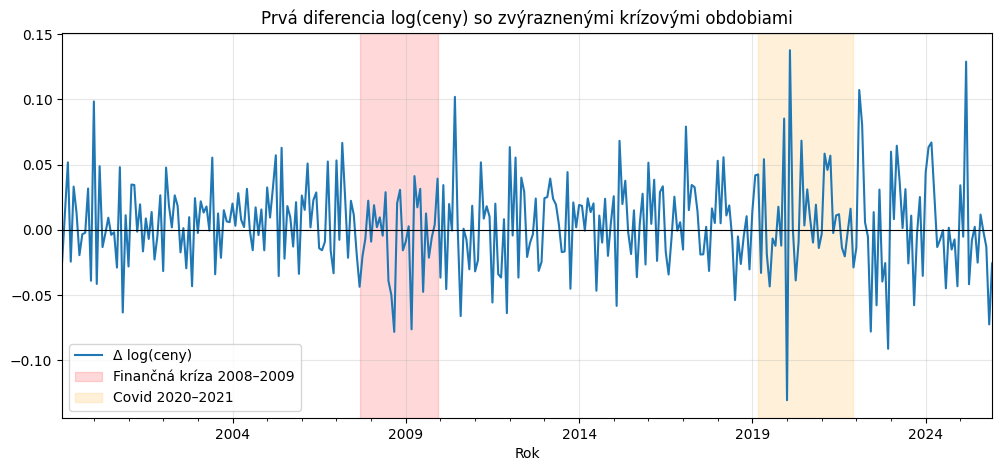

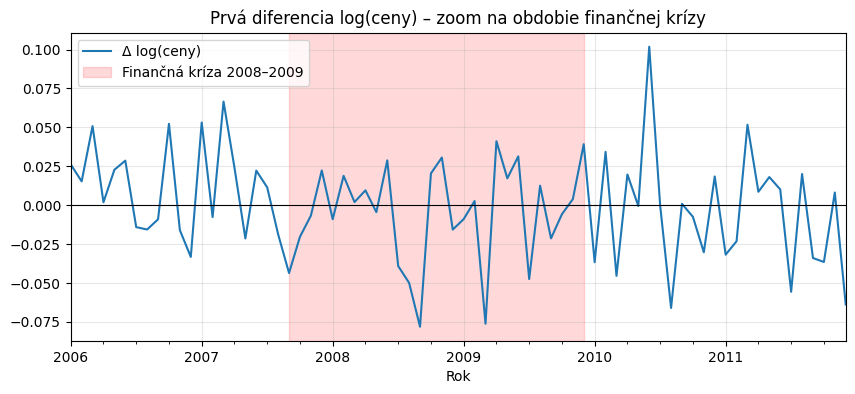

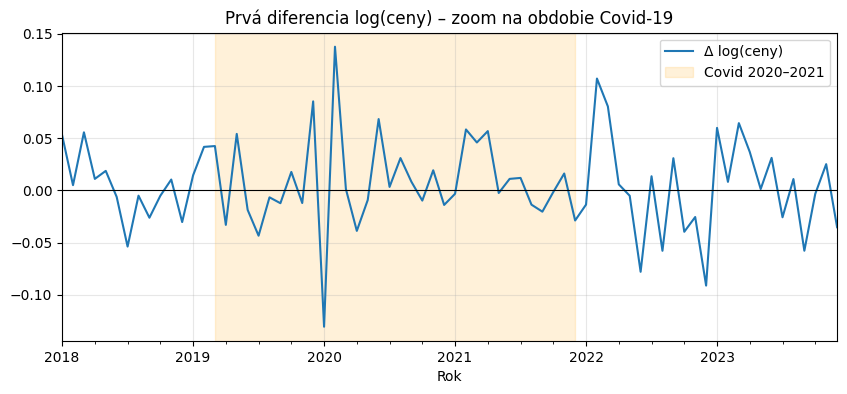

In [51]:
plt.figure(figsize=(12,5))
ts_diff.plot(label='Δ log(ceny)')
plt.axhline(0, color='black', linewidth=0.8)

# horizontálne pásma pre krízu a covid
plt.axvspan('2007-09-01', '2009-12-01', color='red', alpha=0.15, label='Finančná kríza 2008–2009')
plt.axvspan('2019-03-01', '2021-12-01', color='orange', alpha=0.15, label='Covid 2020–2021')

plt.title('Prvá diferencia log(ceny) so zvýraznenými krízovými obdobiami')
plt.xlabel('Rok')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 1) Zoom na finančnú krízu 2007–2010
plt.figure(figsize=(10,4))
ts_diff['2006-01-01':'2011-12-01'].plot(label='Δ log(ceny)')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvspan('2007-09-01', '2009-12-01', color='red', alpha=0.15, label='Finančná kríza 2008–2009')
plt.title('Prvá diferencia log(ceny) – zoom na obdobie finančnej krízy')
plt.xlabel('Rok')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2) Zoom na Covid 2019–2022
plt.figure(figsize=(10,4))
ts_diff['2018-01-01':'2023-12-01'].plot(label='Δ log(ceny)')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvspan('2019-03-01', '2021-12-01', color='orange', alpha=0.15, label='Covid 2020–2021')
plt.title('Prvá diferencia log(ceny) – zoom na obdobie Covid-19')
plt.xlabel('Rok')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



Realitný trh v King County síce reagoval na krízu 2008–2009 a Covid 2020–2021, ale skôr zvýšenou volatilitou (viac extrémnych zmien hore/dole), nie dramatickým dlhodobým pádom cien.


Vplyv vybraných vlastností nehnuteľností na cenový vývoj v čase - napríklad
či rastú ceny luxusných nehnuteľností iným tempom ako bežných domov

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Definícia luxusných nehnuteľností
kingco['luxury'] = (
    (kingco['condition'] >= 4) &
    (kingco['grade'] >= 10) &
    (kingco['sqft'] >= 3000) &
    (kingco['sale_price'] >= kingco['sale_price'].quantile(0.9))
)

# 2. Mesačný priemer cien
kingco['sale_date'] = pd.to_datetime(kingco['sale_date'])
kingco['year_month'] = kingco['sale_date'].dt.to_period('M')

price_summary = kingco.groupby(['year_month', 'luxury'])['sale_price'].agg(['mean', 'count']).reset_index()

# Pivot na dve časové rady: bežné vs. luxusné ceny
price_trend = price_summary.pivot(index='year_month', columns='luxury', values='mean')
price_trend.columns = ['norm_ceny', 'lux_ceny']

price_trend.index = price_trend.index.to_timestamp()
price_trend = price_trend.dropna()

# 3. CAGR výpočet
years = (price_trend.index.max() - price_trend.index.min()).days / 365.25
lux_cagr = (price_trend['lux_ceny'].iloc[-1] / price_trend['lux_ceny'].iloc[0]) ** (1/years) - 1
norm_cagr = (price_trend['norm_ceny'].iloc[-1] / price_trend['norm_ceny'].iloc[0]) ** (1/years) - 1

# Relatívna rýchlosť rastu
relative_growth = lux_cagr / norm_cagr  # luxus / bežné
inverse_growth = norm_cagr / lux_cagr   # bežné / luxus

# Koncové ceny
lux_final = price_trend['lux_ceny'].iloc[-1]
norm_final = price_trend['norm_ceny'].iloc[-1]

# Počiatočné ceny
lux_start = price_trend['lux_ceny'].iloc[0]
norm_start = price_trend['norm_ceny'].iloc[0]

# CAGR
lux_cagr = (lux_final / lux_start) ** (1 / years) - 1
norm_cagr = (norm_final / norm_start) ** (1 / years) - 1


Luxusné domy: $1,905,219 → $3,039,211
Bežné domy: $269,463 → $1,109,384

Perióda: 1999-01 - 2025-12 (26.9 rokov)
Luxusné domy CAGR: 1.75% p.a.
Bežné domy CAGR: 5.40% p.a.
Bežné domy rástli 3.08× rýchlejšie než luxusné domy (32.4% rýchlosti luxusu)

Počet mesiacov s luxusnými dátami: 323
               norm_ceny      lux_ceny
year_month                            
2025-08-01  1.250530e+06  2.956014e+06
2025-09-01  1.247048e+06  3.225748e+06
2025-10-01  1.214872e+06  3.449348e+06
2025-11-01  1.144626e+06  3.657714e+06
2025-12-01  1.109384e+06  3.039211e+06


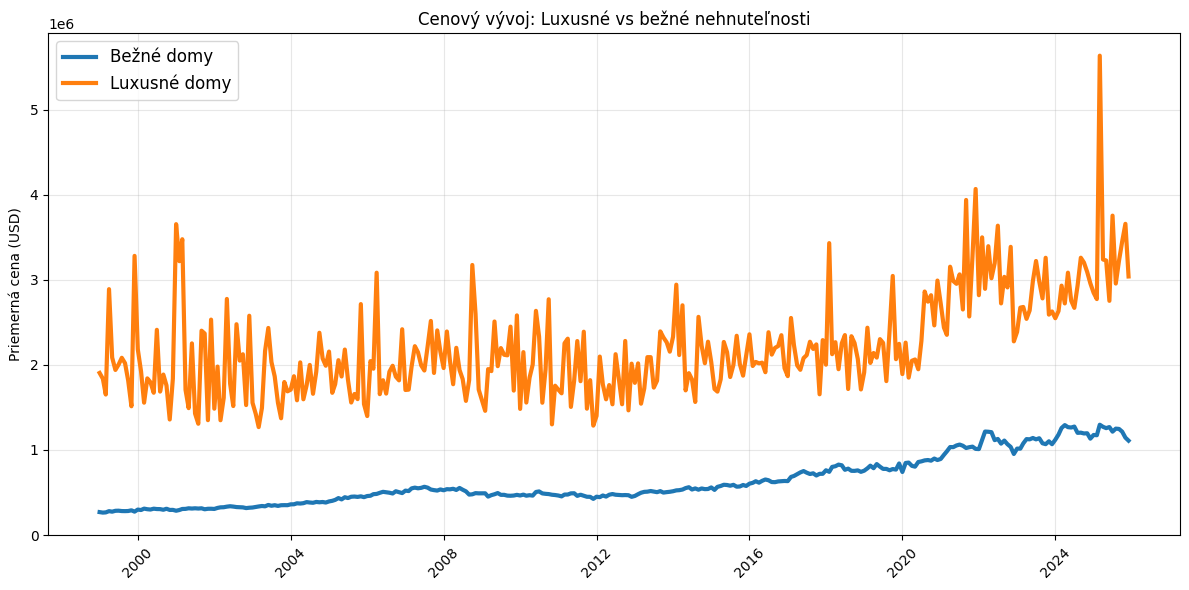

In [53]:
# 4. Výpis výsledkov s jasnou interpretáciou

print(f"Luxusné domy: ${lux_start:,.0f} → ${lux_final:,.0f}")
print(f"Bežné domy: ${norm_start:,.0f} → ${norm_final:,.0f}\n")

print(f'Perióda: {price_trend.index[0].strftime("%Y-%m")} - {price_trend.index[-1].strftime("%Y-%m")} ({years:.1f} rokov)')
print(f'Luxusné domy CAGR: {lux_cagr*100:.2f}% p.a.')
print(f'Bežné domy CAGR: {norm_cagr*100:.2f}% p.a.')
print(f'Bežné domy rástli {inverse_growth:.2f}× rýchlejšie než luxusné domy ({relative_growth*100:.1f}% rýchlosti luxusu)')

print(f"\nPočet mesiacov s luxusnými dátami: {price_trend['lux_ceny'].notna().sum()}")
print(price_trend.tail())

# 5. Graf cenového vývoja
plt.figure(figsize=(12, 6))
plt.plot(price_trend.index, price_trend['norm_ceny'], label='Bežné domy', linewidth=3)
plt.plot(price_trend.index, price_trend['lux_ceny'], label='Luxusné domy', linewidth=3)
plt.ylabel('Priemerná cena (USD)')
plt.title('Cenový vývoj: Luxusné vs bežné nehnuteľnosti')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Luxus vs. bežné – percentuálne: Bežné nehnuteľnosti majú vyšší ročný percentuálny rast (≈ 5.40 % vs. 1.75 % p.a.), takže bežné domy rástli cca 3.08× rýchlejšie než luxusné domy.

Luxus vs. bežné – absolútne: Priemerné ceny luxusných domov sú stále výrazne vyššie (~3,04 M USD vs. ~1.91 M USD), takže investícia do luxusného segmentu prináša vyššiu absolútnu hodnotu, aj keď percentuálny rast je nižší.

Štatistická významnosť: Percentuálny rozdiel rastu (CAGR) ukazuje, že bežné domy rástli rýchlejšie, ale oba segmenty majú stabilný rast, takže trendy sú prakticky konzistentné a predvídateľné.

## 4. Modeling + 5. Evaluation

V tejto časti sa natrénujú a použijú vybrané modely na predikciu časového radu.

V tejto časti sa vyhodnotí presnosť modelov, urobí sa porovnanie, baseline, intervaly spoľahlivosti a štatistické testy rozdielov v chybách.

MODELY

SARIMAX

In [54]:
!pip install pmdarima


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import pmdarima as pm

n_test = 24
train = ts.iloc[:-n_test]
test  = ts.iloc[-n_test:]

sarimax_auto = pm.auto_arima(
    train,
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    d=None,
    seasonal=True,
    m=12,
    start_P=0,
    max_P=2, max_Q=2,
    D=1,
    test='adf',
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(sarimax_auto.summary())

print("Zvolený model:", sarimax_auto.order, "x", sarimax_auto.seasonal_order)


# predikcia na testovacie obdobie
forecast = sarimax_auto.predict(n_periods=n_test)
forecast = pd.Series(forecast, index=test.index)



                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  300
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                 592.655
Date:                              Tue, 17 Feb 2026   AIC                          -1179.310
Time:                                      15:01:32   BIC                          -1168.332
Sample:                                  01-01-1999   HQIC                         -1174.910
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4091      0.043     -9.407      0.000      -0.494      -0.324
ma.S.L12      -0.86


## Nesezónna časť (1, 1, 0)

- **p = 1 (AR(1))**  
  Model používa 1 predchádzajúcu hodnotu log_ceny ako vstup.  
  Hodnota v mesiaci \(t\) závisí (po differencovaní) od hodnoty v mesiaci \(t-1\).

- **d = 1 (prvá diferencia)**  
  Na dosiahnutie stacionarity sa pôvodný rad raz differencuje, t. j. model v skutočnosti pracuje so zmenami log_ceny medzi mesiacmi \(t\) a \(t-1\).

- **q = 0** (bez MA zložky)
Model nepoužíva nesezónnu MA zložku, čo znamená, že aktuálna hodnota nezávisí priamo od predchádzajúcej predikčnej chyby.
Táto voľba naznačuje, že krátkodobé náhodné šoky sú lepšie zachytené sezónnou zložkou.

## Sezónna časť (0, 1, 1, 12)

- **P = 0 (žiadny sezónny AR)**  
  Nepoužíva sa autoregresia na lagoch vzdialených 12, 24 mesiacov atď. (žiadny sezónny AR prvok).

- **D = 1 (sezónna diferencia)**  
  Okrem „obyčajnej“ diferencie \(d=1\) sa robí aj **rozdiel o 12 mesiacov**, teda medzi hodnotami v tom istom mesiaci susedných rokov.  
  Tým sa odstráni ročný sezónny efekt.

- **Q = 1 (sezónny MA(1))**  
  Model berie do úvahy chybu z predikcie spred 12 mesiacov (z rovnakého mesiaca minulého roka).  
  Tým zachytáva sezónne vzory v chybách – napríklad systematické preceňovanie/podceňovanie v určitých mesiacoch.

- **s = 12**  
  Dĺžka sezóny je 12 období, teda 12 mesiacov = 1 rok.  
  Model predpokladá ročnú sezónnosť.



In [56]:
# SARIMAX metriky
sarimax_mae_log = mean_absolute_error(test, forecast)
sarimax_rmse_log = np.sqrt(mean_squared_error(test, forecast))
print("SARIMAX - MAE (log_cena):", sarimax_mae_log)
print("SARIMAX - RMSE (log_cena):", sarimax_rmse_log)

SARIMAX - MAE (log_cena): 0.03979093871433662
SARIMAX - RMSE (log_cena): 0.04905443041863744


Keďže ide o log(cenu), tieto hodnoty sa interpretujú percentuálne:

MAE ≈ 4.2 % - vyjadruje priemernú veľkosť odchýlky medzi
predikovanou a skutočnou hodnotou

RMSE ≈ 5.1 % - zdôrazňuje väčšie chyby

In [57]:
# USD metriky
y_true_price = np.expm1(test)
y_pred_price = np.expm1(forecast)
mae_price = mean_absolute_error(y_true_price, y_pred_price)
rmse_price = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
print("MAE (cena):", mae_price)
print("RMSE (cena):", rmse_price)

MAE (cena): 49135.010203478356
RMSE (cena): 60837.46672566578


In [58]:
from sklearn.metrics import mean_absolute_percentage_error

mape_log_pct = mean_absolute_percentage_error(test, forecast) * 100
mape_usd_pct = mean_absolute_percentage_error(y_true_price, y_pred_price) * 100

print(f"MAPE LOG: {mape_log_pct:.2f}%")
print(f"MAPE USD: {mape_usd_pct:.2f}%")



MAPE LOG: 0.28%
MAPE USD: 3.91%


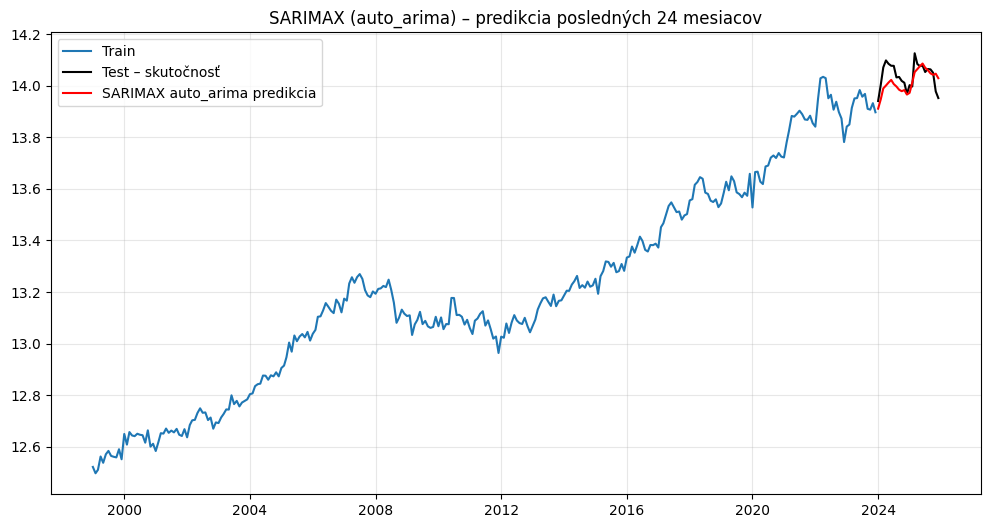

In [59]:
# graf
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test – skutočnosť', color='black')
plt.plot(test.index, forecast, label='SARIMAX auto_arima predikcia', color='red')
plt.title('SARIMAX (auto_arima) – predikcia posledných 24 mesiacov')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



**PROPHET**

In [60]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


# 1. Príprava dát
prophet_df = pd.DataFrame({'ds': ts.index, 'y': ts.values})
ntest = 24  # posledných 24 mesiacov test
prophet_train = prophet_df.iloc[:-ntest].copy()
prophet_test = prophet_df.iloc[-ntest:].copy()

print(f"Train: {len(prophet_train)} mesiacov | Test: {ntest} mesiacov")


Importing plotly failed. Interactive plots will not work.


Train: 300 mesiacov | Test: 24 mesiacov


In [61]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.01,    # hladší trend (najlepší)
    seasonality_prior_scale=10.0,    # silnejšia sezónnosť (najlepší)
    holidays_prior_scale=0.01,       # prakticky vypnuté
    interval_width=0.8
)

# US sviatky
#model.add_country_holidays(country_name='US')

print("Trénujem Prophet...")
model.fit(prophet_train)

15:01:33 - cmdstanpy - INFO - Chain [1] start processing


Trénujem Prophet...


15:01:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet sviatky sú denné efekty ja mám mesačné agregované ceny

Vplyv sviatkov na mesačné priemery cien domov je minimálny až nulový



ale neprinesie reálny prínos alebo uviest, že efekt je zanedbateľný

In [62]:
future = model.make_future_dataframe(periods=ntest, freq='MS')
forecast = model.predict(future)

prophet_forecast = forecast['yhat'].tail(ntest).values


In [63]:
# PROPHET METRIKY
prophet_mae_log = mean_absolute_error(prophet_test['y'], prophet_forecast)
prophet_rmse_log = np.sqrt(mean_squared_error(prophet_test['y'], prophet_forecast))
print("PROPHET - MAE (log_cena):", prophet_mae_log)
print("PROPHET - RMSE (log_cena):", prophet_rmse_log)

PROPHET - MAE (log_cena): 0.06247994930491781
PROPHET - RMSE (log_cena): 0.07823344885228298


In [64]:
# USD metriky
prophet_y_true_price = np.expm1(prophet_test['y'])
prophet_y_pred_price = np.expm1(prophet_forecast)
prophet_mae_price = mean_absolute_error(prophet_y_true_price, prophet_y_pred_price)
prophet_rmse_price = np.sqrt(mean_squared_error(prophet_y_true_price, prophet_y_pred_price))
print("PROPHET - MAE (cena):", prophet_mae_price)
print("PROPHET - RMSE (cena):", prophet_rmse_price)


PROPHET - MAE (cena): 80521.36829310194
PROPHET - RMSE (cena): 100783.48219860386


In [65]:
# PRECÍZNY MAPE
prophet_mape_log_pct = mean_absolute_percentage_error(prophet_test['y'], prophet_forecast) * 100
prophet_mape_usd_pct = mean_absolute_percentage_error(prophet_y_true_price, prophet_y_pred_price) * 100
print(f"PROPHET - MAPE LOG: {prophet_mape_log_pct:.2f}%")
print(f"PROPHET - MAPE USD: {prophet_mape_usd_pct:.2f}%")

PROPHET - MAPE LOG: 0.45%
PROPHET - MAPE USD: 6.55%


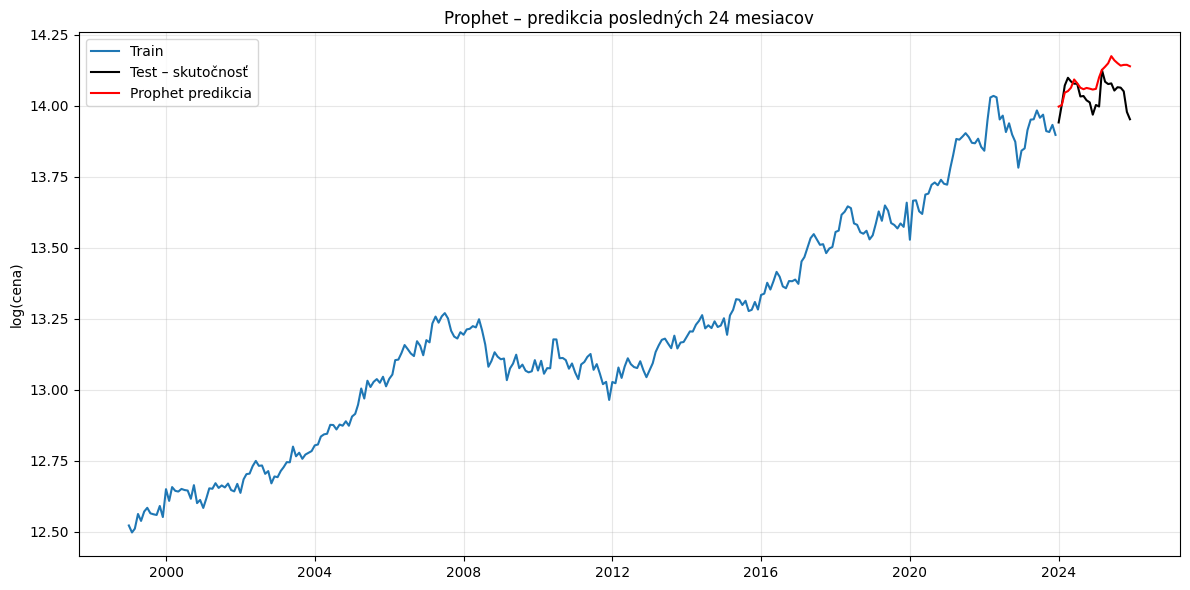

In [66]:
prophet_forecast_24 = forecast.tail(24)
plt.figure(figsize=(12,6))

# Train (celý tréningový úsek)
plt.plot(prophet_train['ds'], prophet_train['y'], label='Train')

# Test – skutočnosť
plt.plot(prophet_test['ds'], prophet_test['y'],
         label='Test – skutočnosť',
         color='black')

# Prophet predikcia
plt.plot(prophet_forecast_24['ds'], prophet_forecast_24['yhat'],
         label='Prophet predikcia',
         color='red')

plt.title('Prophet – predikcia posledných 24 mesiacov')
plt.ylabel('log(cena)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

POROVNANIE SARIMAX vs PROPHET

In [67]:
# POROVNAVACIA TABUĽKA
comparison = pd.DataFrame({
    'Model': ['SARIMAX', 'Prophet'],
    'MAE_log': [sarimax_mae_log, prophet_mae_log],
    'RMSE_log': [sarimax_rmse_log, prophet_rmse_log],
    'MAE_USD': [mae_price, prophet_mae_price],
    'RMSE_USD': [rmse_price, prophet_rmse_price],
    'MAPE_log_%': [mape_log_pct, prophet_mape_log_pct],
    'MAPE_USD_%': [mape_usd_pct, prophet_mape_usd_pct]
}).round(4)

print("POROVNANIE (24 mesiacov test)")
print(comparison.to_markdown(index=False))



POROVNANIE (24 mesiacov test)
| Model   |   MAE_log |   RMSE_log |   MAE_USD |   RMSE_USD |   MAPE_log_% |   MAPE_USD_% |
|:--------|----------:|-----------:|----------:|-----------:|-------------:|-------------:|
| SARIMAX |    0.0398 |     0.0491 |   49135   |    60837.5 |       0.2833 |       3.9083 |
| Prophet |    0.0625 |     0.0782 |   80521.4 |   100783   |       0.4456 |       6.5532 |


NAIVNE BASELINE MODELY

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# Naívny baseline: posledná hodnota z TRAIN sa drží počas celého TEST
naive_forecast = pd.Series(train.iloc[-1],index=test.index)

# --- metriky v log priestore ---
naive_mae_log = mean_absolute_error(test, naive_forecast)
naive_rmse_log = np.sqrt(mean_squared_error(test, naive_forecast))
naive_mape_log_pct = mean_absolute_percentage_error(test, naive_forecast) * 100

# --- metriky v USD ---
naive_mae_usd = mean_absolute_error(np.expm1(test),np.expm1(naive_forecast))
naive_rmse_usd = np.sqrt(mean_squared_error(np.expm1(test),np.expm1(naive_forecast)))
naive_mape_usd_pct = mean_absolute_percentage_error(np.expm1(test),np.expm1(naive_forecast)) * 100


In [69]:
# spoj train+test, aby si mal históriu 12 mesiacov dozadu
full = pd.concat([train, test])

seasonal_forecast = full.shift(12).loc[test.index]  # predikcie presne pre test obdobie

seasonal_mae_log = mean_absolute_error(test, seasonal_forecast)
seasonal_rmse_log = np.sqrt(mean_squared_error(test, seasonal_forecast))
seasonal_mae_usd = mean_absolute_error(np.expm1(test), np.expm1(seasonal_forecast))
seasonal_rmse_usd = np.sqrt(mean_squared_error(np.expm1(test), np.expm1(seasonal_forecast)))
seasonal_mape_log_pct = mean_absolute_percentage_error(test, seasonal_forecast) * 100
seasonal_mape_usd_pct = mean_absolute_percentage_error(np.expm1(test), np.expm1(seasonal_forecast)) * 100


SARIMAX - PROPHET - NAIVNE MODELY

In [70]:
# 3. Rozšírená porovnávacia tabuľka
comparison = pd.DataFrame({
    'Model': ['SARIMAX', 'Prophet', 'Naívny', 'Sezónny naívny'],
    'MAE_log': [sarimax_mae_log, prophet_mae_log, naive_mae_log, seasonal_mae_log],
    'RMSE_log': [sarimax_rmse_log, prophet_rmse_log, naive_rmse_log, seasonal_rmse_log],
    'MAE_USD': [mae_price, prophet_mae_price, naive_mae_usd, seasonal_mae_usd],
    'RMSE_USD': [rmse_price, prophet_rmse_price, naive_rmse_usd, seasonal_rmse_usd],
    'MAPE_log_%': [mape_log_pct, prophet_mape_log_pct, naive_mape_log_pct, seasonal_mape_log_pct],
    'MAPE_USD_%': [mape_usd_pct, prophet_mape_usd_pct, naive_mape_usd_pct, seasonal_mape_usd_pct]
}).round(4)

print("POROVNANIE S BASELINE (24 mesiacov test)")
print(comparison.to_markdown(index=False))


POROVNANIE S BASELINE (24 mesiacov test)
| Model          |   MAE_log |   RMSE_log |   MAE_USD |   RMSE_USD |   MAPE_log_% |   MAPE_USD_% |
|:---------------|----------:|-----------:|----------:|-----------:|-------------:|-------------:|
| SARIMAX        |    0.0398 |     0.0491 |   49135   |    60837.5 |       0.2833 |       3.9083 |
| Prophet        |    0.0625 |     0.0782 |   80521.4 |   100783   |       0.4456 |       6.5532 |
| Naívny         |    0.1423 |     0.1502 |  167300   |   177536   |       1.0125 |      13.1639 |
| Sezónny naívny |    0.0695 |     0.0857 |   82940.1 |   101714   |       0.4953 |       6.6116 |


Rozšírená porovnávacia tabuľka ukazuje, že SARIMAX model prekonáva Prophet aj jednoduché baseline modely (naívny a sezónny naívny) vo všetkých metríkách.
Sezónny naívny model je silný benchmark, pričom Prophet nedosahujpresahuje jeho presnosť a je lepši než sezónny naívny model.
Modely Sarimax a Prophet sú stále výrazne presnejšie než jednoduché naívne modely, ale SARIMAX poskytuje najlepšie výsledky pre mesačnú predikciu.

LSTM MODEL

In [71]:
# =========================
# FINÁLNY MODEL DO DIPLOMOVKY (REPRODUCIBLE):
# LSTM ENSEMBLE (5 seedov) + robustnosť (mean ± std) + baseline seasonal naive
# - cieľ: log_price_mean = log1p(price_mean)
# - split: train/val/test (val=24m, test=24m)
# - bez leakage: scalery fit iba na train
# - featury: lag_1, lag_3, lag_6, lag_12, sin/cos mesiac
# - lookback: 36 mesiacov
# - ENSEMBLE správne: priemer v log1p priestore (nie v USD)
# - REPRODUCIBILITY: pevné seedy + deterministické ops (CPU odporúčaný pre 100% zhodu)
# =========================

# REPRODUCIBILITY BLOK
import os
import random

SEED_GLOBAL = 42
os.environ["PYTHONHASHSEED"] = str(SEED_GLOBAL)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Pre 100% reprodukovateľnosť odporúčam CPU:
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

random.seed(SEED_GLOBAL)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(SEED_GLOBAL)
tf.random.set_seed(SEED_GLOBAL)


try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except Exception:
    pass


In [72]:

# =========================
# 2) VSTUP
# monthly_sales musí existovať a obsahovať:
# - index: MS (mesačný timestamp)
# - log_price_mean = log1p(price_mean)
# =========================
df = monthly_sales.copy()
df = df[['log_price_mean']].copy()
df.index = pd.to_datetime(df.index)
df = df.asfreq("MS")

In [73]:
# 3) FEATURE ENGINEERING (len z minulosti)

for lag in [1, 3, 6, 12]:
    df[f'lag_{lag}'] = df['log_price_mean'].shift(lag)

month = df.index.month
df['sin_m'] = np.sin(2 * np.pi * month / 12)
df['cos_m'] = np.cos(2 * np.pi * month / 12)

df.dropna(inplace=True)

feature_cols = [c for c in df.columns if c != 'log_price_mean']
target_col = 'log_price_mean'

print("Featury:", feature_cols)
print("Počet pozorovaní po dropna:", len(df))

Featury: ['lag_1', 'lag_3', 'lag_6', 'lag_12', 'sin_m', 'cos_m']
Počet pozorovaní po dropna: 312


In [74]:
# 4) TIME SPLIT
test_h = 24
val_h  = 24
lookback = 36

if len(df) <= (test_h + val_h + lookback + 12):
    print("Pozor: málo dát pre zvolený lookback/val/test. Zváž menší lookback alebo kratšie val/test.")

df_train = df.iloc[:-(test_h + val_h)]
df_val   = df.iloc[-(test_h + val_h):-test_h]
df_test  = df.iloc[-test_h:]

print(f"Rows: train={len(df_train)}, val={len(df_val)}, test={len(df_test)}")

X_train_raw = df_train[feature_cols].values
y_train_raw = df_train[[target_col]].values

X_val_raw = df_val[feature_cols].values
y_val_raw = df_val[[target_col]].values

X_test_raw = df_test[feature_cols].values
y_test_raw = df_test[[target_col]].values


Rows: train=264, val=24, test=24


In [75]:
# 5) SCALING (fit iba na TRAIN) – bez leakage

scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(X_train_raw)
scaler_y.fit(y_train_raw)

X_train = scaler_X.transform(X_train_raw)
y_train = scaler_y.transform(y_train_raw).ravel()

X_val = scaler_X.transform(X_val_raw)
y_val = scaler_y.transform(y_val_raw).ravel()

X_test = scaler_X.transform(X_test_raw)
y_test = scaler_y.transform(y_test_raw).ravel()

In [76]:
# 6) SEKVENCIE (lookback kontext pre val/test je OK)

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i + lookback])
        ys.append(y[i + lookback])
    return np.array(Xs), np.array(ys)

def make_seq_from_blocks(X_prev, y_prev, X_block, y_block, lookback):
    X_all = np.vstack([X_prev, X_block])
    y_all = np.concatenate([y_prev, y_block])
    start = len(X_prev) - lookback
    if start < 0:
        raise ValueError("Nedostatok histórie: train je kratší než lookback.")
    Xs, ys = [], []
    for i in range(start, len(X_all) - lookback):
        Xs.append(X_all[i:i + lookback])
        ys.append(y_all[i + lookback])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback)
X_val_seq, y_val_seq = make_seq_from_blocks(X_train, y_train, X_val, y_val, lookback)

X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
X_test_seq, y_test_seq = make_seq_from_blocks(X_tv, y_tv, X_test, y_test, lookback)

n_features = X_train_seq.shape[2]

print("Train seq:", X_train_seq.shape, y_train_seq.shape)
print("Val   seq:", X_val_seq.shape, y_val_seq.shape)
print("Test  seq:", X_test_seq.shape, y_test_seq.shape)

Train seq: (228, 36, 6) (228,)
Val   seq: (24, 36, 6) (24,)
Test  seq: (24, 36, 6) (24,)


In [77]:
# 8) MODEL BUILDER

def build_model(lookback, n_features):
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(64),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')
    return model

def scaled_to_log1p(y_scaled):
    y_scaled = np.asarray(y_scaled)
    if y_scaled.ndim == 1:
        y_scaled = y_scaled.reshape(-1, 1)
    return scaler_y.inverse_transform(y_scaled)

def log1p_to_usd(y_log1p):
    y_log1p = np.asarray(y_log1p).reshape(-1, 1)
    return np.expm1(y_log1p)

# True values na teste (log1p a USD) – 1x pripravené
y_true_log1p = scaled_to_log1p(y_test_seq.reshape(-1, 1))
y_true_usd   = log1p_to_usd(y_true_log1p)

In [78]:
# 9) ROBUSTNOSŤ + ENSEMBLE (seeds)
# - per-seed metriky v USD
# - ensemble priemer v log1p priestore (správne)
# =========================
seeds = [1, 7, 21, 42, 100]

mape_per_seed = []
mae_per_seed  = []
rmse_per_seed = []

preds_log1p = []  # pre ensemble (log1p)

for s in seeds:
    tf.keras.backend.clear_session()

    # nastav seedy pre daný beh
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s)
    np.random.seed(s)
    tf.random.set_seed(s)
    try:
        tf.keras.utils.set_random_seed(s)  # novšie TF, keď je dostupné
    except Exception:
        pass

    model = build_model(lookback, n_features)

    early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
    lr_reduce  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

    model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=300,
        batch_size=8,
        callbacks=[early_stop, lr_reduce],
        verbose=0,
        shuffle=False  # dôležité pre deterministiku
    )

    y_pred_scaled = model.predict(X_test_seq, verbose=0)  # (24,1) scaled
    y_pred_log1p  = scaled_to_log1p(y_pred_scaled)        # (24,1) log1p
    preds_log1p.append(y_pred_log1p)

    y_pred_usd = log1p_to_usd(y_pred_log1p)

    mape = mean_absolute_percentage_error(y_true_usd, y_pred_usd) * 100
    mae  = mean_absolute_error(y_true_usd, y_pred_usd)
    rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))

    mape_per_seed.append(float(mape))
    mae_per_seed.append(float(mae))
    rmse_per_seed.append(float(rmse))

print("\nLSTM (5 seeds) - MAPE per seed:", [round(x, 2) for x in mape_per_seed])
print(f"LSTM (5 seeds) - MAPE mean: {np.mean(mape_per_seed):.2f}%")
print(f"LSTM (5 seeds) - MAPE std : {np.std(mape_per_seed):.2f}%")



LSTM (5 seeds) - MAPE per seed: [3.58, 4.15, 3.68, 4.33, 3.98]
LSTM (5 seeds) - MAPE mean: 3.94%
LSTM (5 seeds) - MAPE std : 0.28%


In [79]:
# 10) METRIKY
y_pred_log1p_ens = np.mean(preds_log1p, axis=0)  # (24,1) log1p
y_pred_usd_ens   = log1p_to_usd(y_pred_log1p_ens)

# Metriky ensemble (USD)
mape_usd_lstm = mean_absolute_percentage_error(y_true_usd, y_pred_usd_ens) * 100
mae_usd_lstm  = mean_absolute_error(y_true_usd, y_pred_usd_ens)
rmse_usd_lstm = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd_ens))

# Metriky v log1p priestore (odporúčané: MAE/RMSE, NIE MAPE)
mae_log_lstm  = mean_absolute_error(y_true_log1p, y_pred_log1p_ens)
rmse_log_lstm = np.sqrt(mean_squared_error(y_true_log1p, y_pred_log1p_ens))

print(f"\nLSTM ENSEMBLE (mean of {len(seeds)} seeds) - MAPE USD (%): {mape_usd_lstm:.2f}%")
print(f"LSTM ENSEMBLE - MAE USD: {mae_usd_lstm:.2f}")
print(f"LSTM ENSEMBLE - RMSE USD: {rmse_usd_lstm:.2f}")
print(f"LSTM ENSEMBLE - MAE log1p: {mae_log_lstm:.4f}")
print(f"LSTM ENSEMBLE - RMSE log1p: {rmse_log_lstm:.4f}")


LSTM ENSEMBLE (mean of 5 seeds) - MAPE USD (%): 3.88%
LSTM ENSEMBLE - MAE USD: 49253.98
LSTM ENSEMBLE - RMSE USD: 61184.46
LSTM ENSEMBLE - MAE log1p: 0.0397
LSTM ENSEMBLE - RMSE log1p: 0.0491


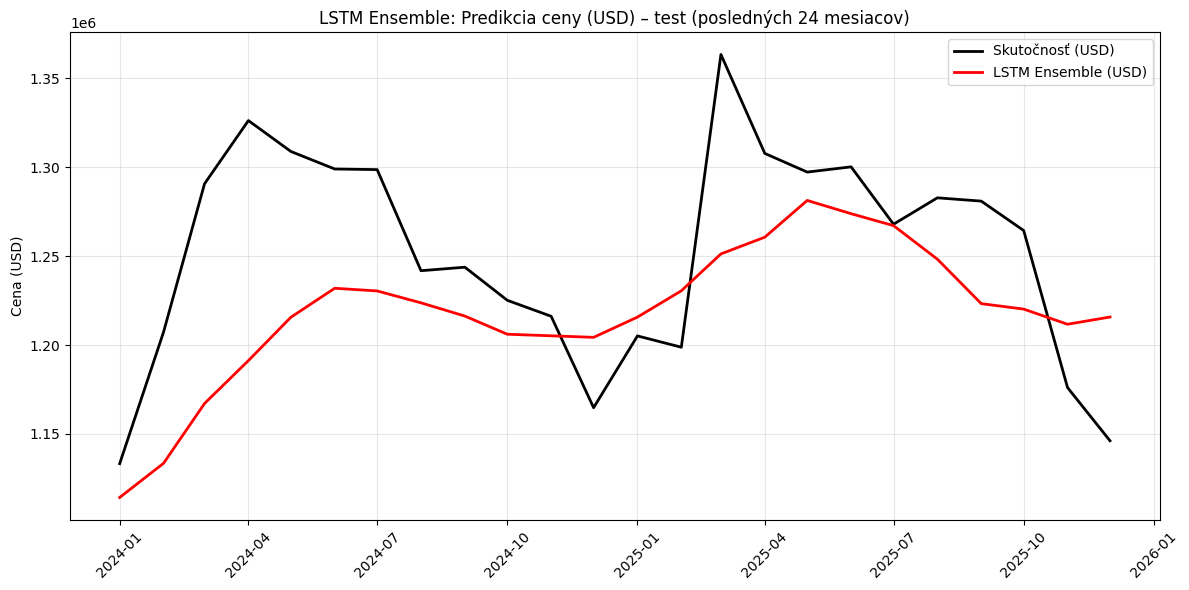

In [80]:
# 11) GRAF: test vs ensemble (USD)

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, y_true_usd, label="Skutočnosť (USD)", linewidth=2, color="black")
plt.plot(df_test.index, y_pred_usd_ens, label="LSTM Ensemble (USD)", linewidth=2, color="red")
plt.title("LSTM Ensemble: Predikcia ceny (USD) – test (posledných 24 mesiacov)")
plt.ylabel("Cena (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


POROVNANIE MODELOV

In [81]:
import numpy as np
import pandas as pd


comparison = pd.DataFrame({
    'Model': ['SARIMAX', 'Prophet', 'Naívny', 'Sezónny naívny', 'LSTM ensemble'],

    # LOG1P PRIESTOR
    'MAE_log1p': [
        sarimax_mae_log,
        prophet_mae_log,
        naive_mae_log,
        seasonal_mae_log,
        mae_log_lstm
    ],
    'RMSE_log1p': [
        sarimax_rmse_log,
        prophet_rmse_log,
        naive_rmse_log,
        seasonal_rmse_log,
        rmse_log_lstm
    ],

    # MAPE v log priestore – pre LSTM prázdne (NaN)
    'MAPE_log_%': [
        mape_log_pct,
        prophet_mape_log_pct,
        naive_mape_log_pct,
        seasonal_mape_log_pct,
        np.nan
    ],

    # USD PRIESTOR
    'MAE_USD': [
        mae_price,
        prophet_mae_price,
        naive_mae_usd,
        seasonal_mae_usd,
        mae_usd_lstm
    ],
    'RMSE_USD': [
        rmse_price,
        prophet_rmse_price,
        naive_rmse_usd,
        seasonal_rmse_usd,
        rmse_usd_lstm
    ],
    'MAPE_USD_%': [
        mape_usd_pct,
        prophet_mape_usd_pct,
        naive_mape_usd_pct,
        seasonal_mape_usd_pct,
        mape_usd_lstm
    ]
})

comparison_fmt = comparison.copy()
for c in ['MAE_log1p', 'RMSE_log1p', 'MAPE_log_%', 'MAPE_USD_%']:
    comparison_fmt[c] = comparison_fmt[c].round(4)
for c in ['MAE_USD', 'RMSE_USD']:
    comparison_fmt[c] = comparison_fmt[c].round(0)

print("\nPOROVNANIE MODELOV (test = 24 mesiacov)")
print(comparison_fmt.to_markdown(index=False))



POROVNANIE MODELOV (test = 24 mesiacov)
| Model          |   MAE_log1p |   RMSE_log1p |   MAPE_log_% |   MAE_USD |   RMSE_USD |   MAPE_USD_% |
|:---------------|------------:|-------------:|-------------:|----------:|-----------:|-------------:|
| SARIMAX        |      0.0398 |       0.0491 |       0.2833 |     49135 |      60837 |       3.9083 |
| Prophet        |      0.0625 |       0.0782 |       0.4456 |     80521 |     100783 |       6.5532 |
| Naívny         |      0.1423 |       0.1502 |       1.0125 |    167300 |     177536 |      13.1639 |
| Sezónny naívny |      0.0695 |       0.0857 |       0.4953 |     82940 |     101714 |       6.6116 |
| LSTM ensemble  |      0.0397 |       0.0491 |     nan      |     49254 |      61184 |       3.8801 |


Ljung–Box (nezávislosť rezíduí)

Jarque–Bera (normalita)

ARCH test (heteroskedasticita)



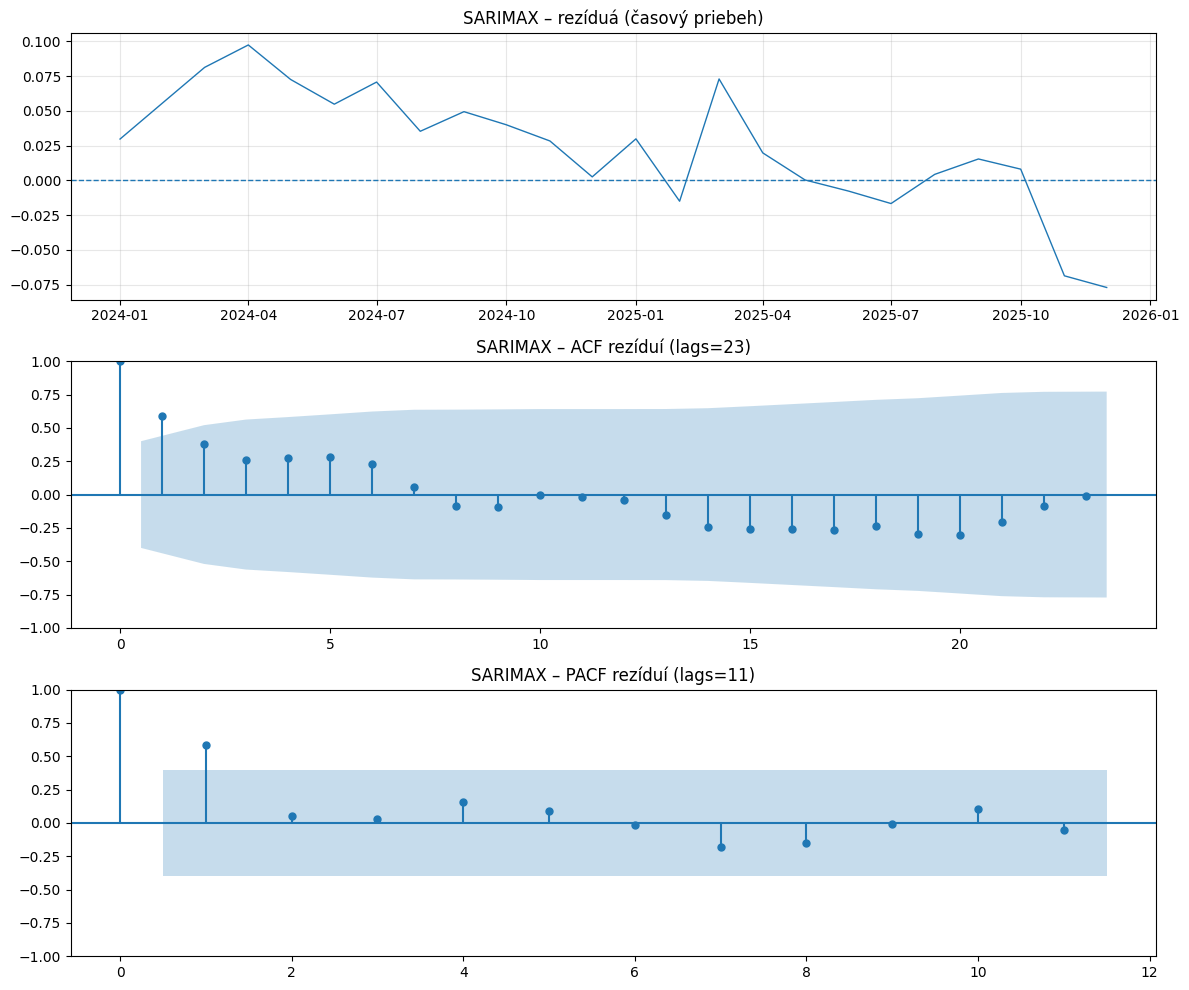


=== SARIMAX – diagnostika ===
n=24 | mean=0.024354 | std=0.043498
ACF lags=23 | PACF lags=11 | Ljung-Box lag=12
Ljung–Box p-value: 0.026845  (H0: nezávislosť)
Jarque–Bera p-value: 0.513914 (H0: normalita)
ARCH p-value: 0.323979      (H0: bez heteroskedasticity)
Skew=-0.5744 | Kurtosis=3.1080


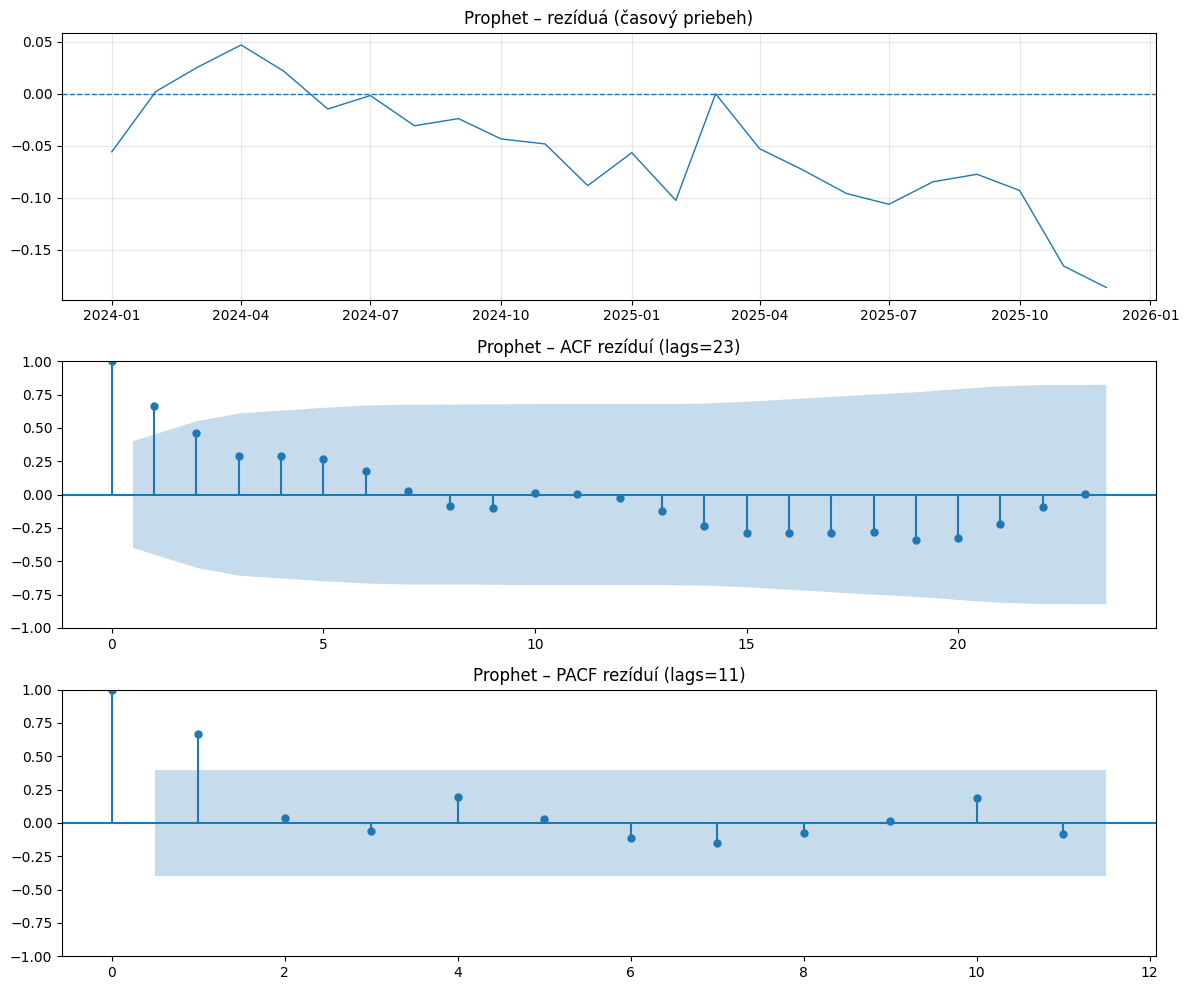


=== Prophet – diagnostika ===
n=24 | mean=-0.054485 | std=0.057349
ACF lags=23 | PACF lags=11 | Ljung-Box lag=12
Ljung–Box p-value: 0.007257  (H0: nezávislosť)
Jarque–Bera p-value: 0.757078 (H0: normalita)
ARCH p-value: 0.005760      (H0: bez heteroskedasticity)
Skew=-0.3688 | Kurtosis=2.8875


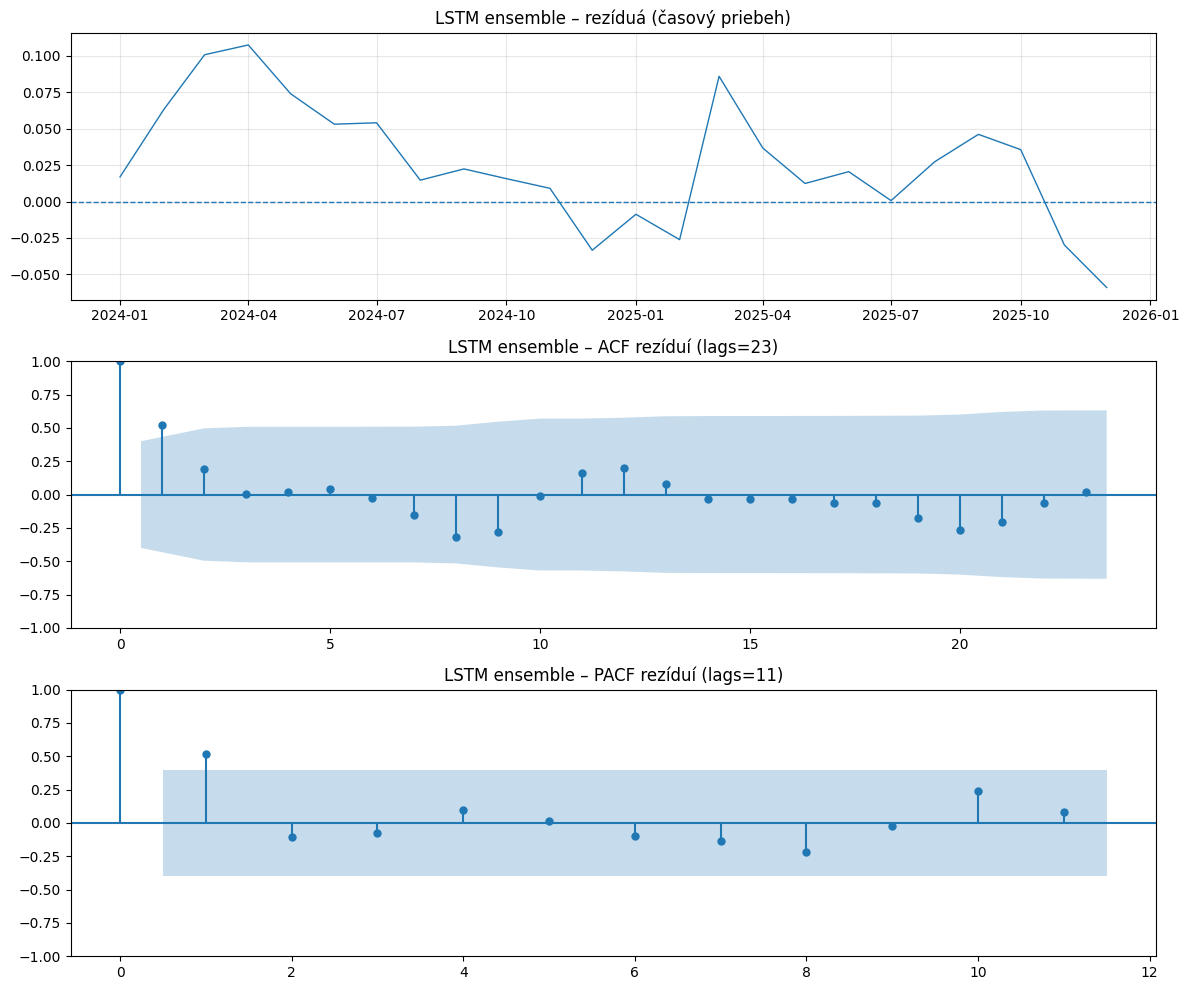


=== LSTM ensemble – diagnostika ===
n=24 | mean=0.026620 | std=0.042153
ACF lags=23 | PACF lags=11 | Ljung-Box lag=12
Ljung–Box p-value: 0.071621  (H0: nezávislosť)
Jarque–Bera p-value: 0.911125 (H0: normalita)
ARCH p-value: 0.209955      (H0: bez heteroskedasticity)
Skew=0.0593 | Kurtosis=2.5852


,n,acf_lags,pacf_lags,lb_lag,LB_pvalue,JB_pvalue,ARCH_pvalue,mean,std
Model,,,,,,,,,
SARIMAX,24,23,11,12,0.026845,0.513914,0.323979,0.024354,0.043498
Prophet,24,23,11,12,0.007257,0.757078,0.005760,-0.054485,0.057349
LSTM ensemble,24,23,11,12,0.071621,0.911125,0.209955,0.026620,0.042153


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera


def residual_diagnostics(resid: pd.Series, lags: int = 24, name: str = "") -> dict:
    resid = pd.Series(resid).dropna().astype(float)
    n = len(resid)

    if n < 8:
        raise ValueError(f"{name}: príliš málo rezíduí (n={n}) na diagnostiku.")

    # ACF: max n-1 (kvôli lag0)
    acf_lags = int(min(lags, n - 1))

    # PACF: statsmodels limit ~ < n/2
    pacf_max = max(1, (n // 2) - 1)
    pacf_lags = int(min(lags, pacf_max))

    # Grafy
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    axes[0].plot(resid.index, resid.values, linewidth=1)
    axes[0].axhline(0, linestyle="--", linewidth=1)
    axes[0].set_title(f"{name} – rezíduá (časový priebeh)")
    axes[0].grid(True, alpha=0.3)

    plot_acf(resid.values, lags=acf_lags, ax=axes[1])
    axes[1].set_title(f"{name} – ACF rezíduí (lags={acf_lags})")

    plot_pacf(resid.values, lags=pacf_lags, ax=axes[2], method="ywm")
    axes[2].set_title(f"{name} – PACF rezíduí (lags={pacf_lags})")

    plt.tight_layout()
    plt.show()

    # Testy
    # Ljung-Box: H0 = nezávislosť rezíduí (biely šum)
    lb_lag = min(lags, max(1, n // 2))
    lb = acorr_ljungbox(resid, lags=[lb_lag], return_df=True)
    lb_p = float(lb["lb_pvalue"].iloc[0])

    # Jarque-Bera: H0 = normalita
    jb_stat, jb_p, skew, kurt = jarque_bera(resid)

    # ARCH: H0 = bez ARCH efektu (homoskedasticita)
    arch_stat, arch_p, _, _ = het_arch(resid)

    print(f"\n=== {name} – diagnostika ===")
    print(f"n={n} | mean={resid.mean():.6f} | std={resid.std():.6f}")
    print(f"ACF lags={acf_lags} | PACF lags={pacf_lags} | Ljung-Box lag={lb_lag}")
    print(f"Ljung–Box p-value: {lb_p:.6f}  (H0: nezávislosť)")
    print(f"Jarque–Bera p-value: {jb_p:.6f} (H0: normalita)")
    print(f"ARCH p-value: {arch_p:.6f}      (H0: bez heteroskedasticity)")
    print(f"Skew={skew:.4f} | Kurtosis={kurt:.4f}")

    return {
        "Model": name,
        "n": n,
        "acf_lags": acf_lags,
        "pacf_lags": pacf_lags,
        "lb_lag": lb_lag,
        "LB_pvalue": lb_p,
        "JB_pvalue": float(jb_p),
        "ARCH_pvalue": float(arch_p),
        "mean": float(resid.mean()),
        "std": float(resid.std()),
    }


# 1) SARIMAX rezíduá (log priestor) – bezpečne prepočítaj forecast
n_test = 24
sarimax_forecast = sarimax_auto.predict(n_periods=n_test)
sarimax_forecast = pd.Series(sarimax_forecast, index=test.index, name="sarimax_forecast")

sarimax_resid = (test - sarimax_forecast).rename("sarimax_resid")


# 2) Prophet rezíduá (log priestor)
# prophet_test['y'] je Series v log priestore, prophet_forecast je numpy
prophet_pred = pd.Series(prophet_forecast, index=prophet_test["ds"].values, name="prophet_pred")
prophet_true = pd.Series(prophet_test["y"].values, index=prophet_test["ds"].values, name="prophet_true")

prophet_resid = (prophet_true - prophet_pred).rename("prophet_resid")



# 3) LSTM ensemble rezíduá (log1p priestor)
# y_true_log1p a y_pred_log1p_ens existujú v tvojom notebooku
# y_pred_log1p_ens má často shape (24,1) – sploštime
y_pred_log1p_ens_1d = np.asarray(y_pred_log1p_ens).reshape(-1)

lstm_true = pd.Series(np.asarray(y_true_log1p).reshape(-1), index=df_test.index, name="lstm_true")
lstm_pred = pd.Series(y_pred_log1p_ens_1d, index=df_test.index, name="lstm_pred")

lstm_resid = (lstm_true - lstm_pred).rename("lstm_resid")


# Spusti diagnostiku pre všetky 3 modely
results = []
results.append(residual_diagnostics(sarimax_resid, lags=24, name="SARIMAX"))
results.append(residual_diagnostics(prophet_resid, lags=24, name="Prophet"))
results.append(residual_diagnostics(lstm_resid, lags=24, name="LSTM ensemble"))

diag_table = pd.DataFrame(results).set_index("Model")
display(diag_table)


Diebold–Mariano test

In [83]:
import numpy as np
from scipy import stats


def diebold_mariano(y_true, y_pred1, y_pred2, h=1, power=2):
    """
    Diebold-Mariano test
    y_true  : skutočné hodnoty
    y_pred1 : predikcie modelu 1
    y_pred2 : predikcie modelu 2
    h       : forecast horizon (1 = one-step)
    power   : 1 = MAE, 2 = MSE
    """

    y_true = np.asarray(y_true).reshape(-1)
    y_pred1 = np.asarray(y_pred1).reshape(-1)
    y_pred2 = np.asarray(y_pred2).reshape(-1)

    # chyba
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2

    # stratová funkcia
    if power == 1:
        d = np.abs(e1) - np.abs(e2)
    else:
        d = e1**2 - e2**2

    T = len(d)
    mean_d = np.mean(d)

    # Newey-West odhad rozptylu
    gamma = [np.sum((d[:T-k] - mean_d)*(d[k:] - mean_d))/T for k in range(h)]
    var_d = gamma[0] + 2 * sum(gamma[1:])

    DM_stat = mean_d / np.sqrt(var_d / T)

    p_value = 2 * (1 - stats.norm.cdf(abs(DM_stat)))

    return DM_stat, p_value


In [84]:

# SARIMAX
sarimax_pred = sarimax_forecast.values
sarimax_true = test.values

# Prophet
prophet_pred = prophet_forecast
prophet_true = prophet_test["y"].values

# LSTM ensemble
lstm_pred = y_pred_log1p_ens.reshape(-1)
lstm_true = y_true_log1p.reshape(-1)

# ===== TESTY =====

pairs = [
    ("LSTM vs SARIMAX", lstm_true, lstm_pred, sarimax_pred),
    ("LSTM vs Prophet", lstm_true, lstm_pred, prophet_pred),
    ("SARIMAX vs Prophet", sarimax_true, sarimax_pred, prophet_pred),
]

results_dm = []

for name, y, p1, p2 in pairs:
    stat, pval = diebold_mariano(y, p1, p2, h=1, power=2)
    print(f"{name}: DM stat = {stat:.4f}, p-value = {pval:.6f}")
    results_dm.append((name, stat, pval))


LSTM vs SARIMAX: DM stat = 0.0156, p-value = 0.987586
LSTM vs Prophet: DM stat = -1.9145, p-value = 0.055562
SARIMAX vs Prophet: DM stat = -2.1084, p-value = 0.034996


| Porovnanie         | Výsledok                       |
| ------------------ | ------------------------------ |
| LSTM vs SARIMAX    | žiadny rozdiel                 |
| LSTM vs Prophet    | LSTM lepší (hranične významné) |
| SARIMAX vs Prophet | SARIMAX lepší (významné)       |


Wilcoxon test

In [85]:
from scipy.stats import wilcoxon

abs_errors = pd.DataFrame({
    'sarimax': np.abs(sarimax_true - sarimax_pred),
    'prophet': np.abs(prophet_true - prophet_pred),
    'lstm': np.abs(lstm_true - lstm_pred)
})

w_sar_lstm, p_w_sarl = wilcoxon(abs_errors['sarimax'], abs_errors['lstm'])
w_pro_lstm, p_w_prol = wilcoxon(abs_errors['prophet'], abs_errors['lstm'])

print(f"Wilcoxon SAR-LSTM p={p_w_sarl:.3f}")
print(f"Wilcoxon Pro-LSTM p={p_w_prol:.3f}")


Wilcoxon SAR-LSTM p=0.922
Wilcoxon Pro-LSTM p=0.152


| Porovnanie         | DM test    | Wilcoxon                    | Interpretácia                    |
| ------------------ | ---------- | --------------------------- | -------------------------------- |
| LSTM vs SARIMAX    | nevýznamné | nevýznamné                  | rovnaká presnosť                 |
| LSTM vs Prophet    | hraničné   | nevýznamné                  | slabší Prophet, ale nie robustne |
| SARIMAX vs Prophet | významné   | (implicitne slabší Prophet) | Prophet najslabší                |


In [86]:
# SARIMAX intervaly (pmdarima)
sarimax_pred, sarimax_ci = sarimax_auto.predict(n_periods=n_test, return_conf_int=True, alpha=0.05)
sarimax_pred = pd.Series(sarimax_pred, index=test.index)
sarimax_low  = pd.Series(sarimax_ci[:,0], index=test.index)
sarimax_high = pd.Series(sarimax_ci[:,1], index=test.index)


In [87]:
# Prophet intervaly (forecast dataframe)
# prophet_model.predict(future) -> dataframe s yhat_lower/yhat_upper
prophet_low  = pd.Series(forecast['yhat_lower'].values[-n_test:], index=prophet_test['ds'])
prophet_high = pd.Series(forecast['yhat_upper'].values[-n_test:], index=prophet_test['ds'])


In [88]:
import numpy as np
import pandas as pd

def interval_metrics(y_true, low, high):
    df = pd.concat(
        [
            pd.Series(y_true, name="y"),
            pd.Series(low, name="low"),
            pd.Series(high, name="high"),
        ],
        axis=1
    ).dropna()

    y = df["y"].to_numpy()
    lo = df["low"].to_numpy()
    hi = df["high"].to_numpy()

    covered = np.mean((y >= lo) & (y <= hi))
    width = np.mean(hi - lo)
    return covered, width, len(df)

# SARIMAX (dôležité: daj mu rovnaký index ako test)
y_sar = pd.Series(test.values, index=test.index)
cov_sar, wid_sar, n_sar = interval_metrics(y_sar, sarimax_low, sarimax_high)

# Prophet (ak máš prophet_true/pred s ds indexom)
y_pro = pd.Series(prophet_true, index=prophet_test["ds"].values)
cov_pro, wid_pro, n_pro = interval_metrics(y_pro, prophet_low, prophet_high)

print(f"SARIMAX: n={n_sar}, coverage={cov_sar:.3f}, width={wid_sar:.4f}")
print(f"Prophet: n={n_pro}, coverage={cov_pro:.3f}, width={wid_pro:.4f}")


SARIMAX: n=24, coverage=0.917, width=0.2986
Prophet: n=24, coverage=0.500, width=0.1112


In [89]:
import numpy as np
import pandas as pd


# index test obdobia
test_index = df_test.index

# true hodnoty
lstm_true_series = pd.Series(
    np.asarray(lstm_true).reshape(-1),
    index=test_index,
    name="lstm_true"
)

# predikcie
lstm_pred_series = pd.Series(
    np.asarray(lstm_pred).reshape(-1),
    index=test_index,
    name="lstm_pred"
)

# rezíduá
lstm_resid = (lstm_true_series - lstm_pred_series).rename("lstm_resid")

# 2) Kvantily rezíduí (95% interval)
q_low, q_high = np.quantile(lstm_resid.values, [0.025, 0.975])

print(f"LSTM residual quantiles: q2.5={q_low:.6f}, q97.5={q_high:.6f}")

# 3) Intervaly
lstm_low = (lstm_pred_series + q_low).rename("lstm_low")
lstm_high = (lstm_pred_series + q_high).rename("lstm_high")

# 4) Coverage + width
coverage = np.mean(
    (lstm_true_series >= lstm_low) &
    (lstm_true_series <= lstm_high)
)

width = np.mean(lstm_high - lstm_low)

print(f"LSTM: n={len(lstm_true_series)}, coverage={coverage:.3f}, width={width:.4f}")


LSTM residual quantiles: q2.5=-0.044281, q97.5=0.103561
LSTM: n=24, coverage=0.917, width=0.1478


In [90]:
# premenujeme LSTM výsledky pre konzistenciu
cov_lstm = coverage
wid_lstm = width

interval_summary = pd.DataFrame({
    "Coverage (95%)": [cov_sar, cov_pro, cov_lstm],
    "Avg Interval Width": [wid_sar, wid_pro, wid_lstm],
    "Calibration Error": [
        abs(0.95 - cov_sar),
        abs(0.95 - cov_pro),
        abs(0.95 - cov_lstm)
    ]
}, index=["SARIMAX", "Prophet", "LSTM (residual PI)"])

display(interval_summary.round(4))


,Coverage (95%),Avg Interval Width,Calibration Error
SARIMAX,0.9167,0.2986,0.0333
Prophet,0.5000,0.1112,0.4500
LSTM (residual PI),0.9167,0.1478,0.0333


Prophet je štatisticky aj intervalovo najslabší model.

SARIMAX je robustný a konzervatívny model.

LSTM dosahuje rovnakú presnosť ako SARIMAX.

LSTM je lepšie špecifikovaný.

LSTM poskytuje efektívnejšie intervaly pri zachovaní kalibrácie.

N = 324 mesiacov, spoľahlivé periódy ~ [13, 162.0]
Top píky (perióda v mesiacoch) + sila:
- 42.7 mesiacov | PSD=0.05759
- 17.1 mesiacov | PSD=0.001296
- 21.3 mesiacov | PSD=0.0008794
- 15.1 mesiacov | PSD=0.000829


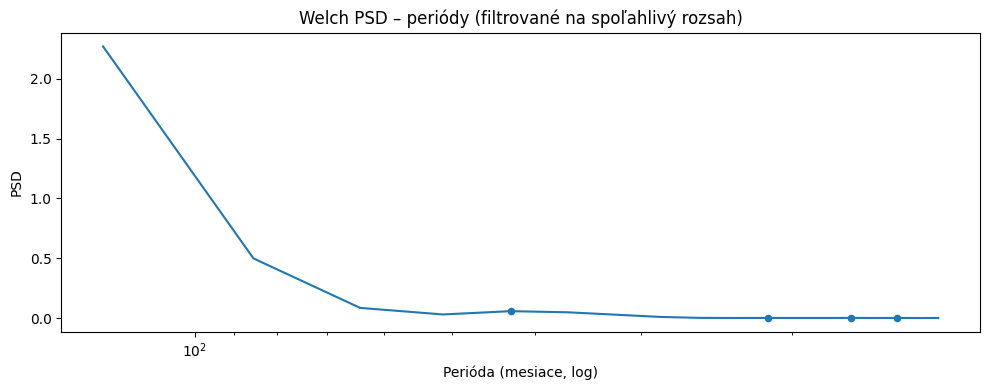

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, detrend, find_peaks

y = monthly_sales['log_price_mean'].dropna()
N = len(y)

y_dt = detrend(y.values)
fs = 1.0  # 1 vzorka / mesiac
freqs, psd = welch(y_dt, fs=fs, nperseg=min(256, N))

mask = freqs > 0
freqs2, psd2 = freqs[mask], psd[mask]
periods = 1.0 / freqs2

# Spoľahlivý rozsah periód:
# - viac než 12 mesiacov (mimo sezónnosti)
# - menej než N/2 (aby si nemeral "cyklus" dlhší než polovica dát)
valid = (periods >= 13) & (periods <= (N/2))

p = periods[valid]
s = psd2[valid]

# nájdi lokálne maximá (píky)
peaks, _ = find_peaks(s)
peak_periods = p[peaks]
peak_power = s[peaks]

# top 5 píkov
top_idx = np.argsort(peak_power)[-5:][::-1]

print(f"N = {N} mesiacov, spoľahlivé periódy ~ [13, {N/2:.1f}]")
print("Top píky (perióda v mesiacoch) + sila:")
for pp, pw in zip(peak_periods[top_idx], peak_power[top_idx]):
    print(f"- {pp:.1f} mesiacov | PSD={pw:.4g}")

plt.figure(figsize=(10,4))
plt.plot(p, s)
plt.scatter(peak_periods, peak_power, s=20)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.title("Welch PSD – periódy (filtrované na spoľahlivý rozsah)")
plt.xlabel("Perióda (mesiace, log)")
plt.ylabel("PSD")
plt.tight_layout()
plt.show()


Spektrálna analýza pomocou Welchovej metódy po odstránení trendu identifikovala dominantnú frekvenčnú zložku s periódou približne 42.7 mesiaca (≈ 3.6 roka). Táto periodicita naznačuje prítomnosť strednodobého cyklického správania cien nehnuteľností. Ostatné detegované frekvencie vykazovali zanedbateľnú energetickú úroveň a neboli považované za významné cyklické komponenty.